# Summative Lab — DataVine Analytics

**Junior Data Scientist | Prototype Machine Learning Solutions**

Three client projects, one end-to-end machine learning workflow:

| # | Client | Dataset | Technique |
|---|--------|---------|-----------|
| 1 | Premium wine distributor | `Wine` (178 x 14) | k-NN classification + PCA + GridSearchCV |
| 2 | Agricultural supply company | `chickwts` (71 x 2) | Recommendation engine: PCA + cosine similarity |
| 3 | Public policy research firm | `USArrests` (50 x 4) | K-Means + Gaussian Mixture Models |

**Notebook structure**

1. Dataset Preparation — inspection, cleaning, standardisation
2. Wine Classification System — k-NN with PCA and hyper-parameter tuning
3. Agricultural Feed Recommendation Engine — PCA and cosine similarity
4. Regional Crime Pattern Analysis — feature selection, PCA, K-Means and GMM
5. Model Evaluation and Interpretation — metrics, visualisation, business insight

## 0. Environment Setup

All libraries, plotting defaults and the global random seed are fixed here so every result in this
notebook is reproducible.

In [1]:
# Core
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & decomposition
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# Model selection & metrics
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             silhouette_score, adjusted_rand_score)
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 5), "figure.dpi": 100,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11, "font.size": 10,
})
sns.set_palette("deep")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

print(f"Environment ready | random_state = {RANDOM_STATE}")

Environment ready | random_state = 42


---
# 1. Dataset Preparation

> **Rubric:** *Inspect the Wine, Chickwts and USArrests datasets for missing values and handle
> inconsistencies. Clearly standardise numerical features to improve model performance.*

## 1.1 Loading the three datasets

All three CSVs are read from the local project directory. `DATA_DIR` is defined once so the paths can
be repointed in a single place if the files are kept in a subfolder.

In [2]:
# Local project directory holding the three CSVs.
# Change this one line if the data lives elsewhere, e.g. Path("data") or Path(r"C:\Users\...\data")
DATA_DIR = Path(".")


def load_dataset(filename: str) -> pd.DataFrame:
    """Read a dataset CSV from the local data directory."""
    path = DATA_DIR / filename
    if not path.exists():
        raise FileNotFoundError(
            f"'{filename}' not found in {path.parent.resolve()}. "
            f"Place the CSV in that folder or update DATA_DIR."
        )
    df = pd.read_csv(path)
    print(f"  {filename:<16} {df.shape[0]:>4} rows x {df.shape[1]:>2} cols   <-  {path}")
    return df


print(f"Loading datasets from: {DATA_DIR.resolve()}")
print()
wine_raw      = load_dataset("wine.csv")
chickwts_raw  = load_dataset("chickwts.csv")
usarrests_raw = load_dataset("USArrests.csv")

Loading datasets from: /home/claude/build

  wine.csv          178 rows x 14 cols   <-  wine.csv
  chickwts.csv       71 rows x  3 cols   <-  chickwts.csv
  USArrests.csv      50 rows x  5 cols   <-  USArrests.csv


### Tidying the R index column

`chickwts.csv` and `USArrests.csv` come from R and carry an extra `rownames` column. For `USArrests`
those row names are the **state names** — genuine labels that must be preserved as the index rather
than treated as a feature. For `chickwts` the row names are a meaningless sequence and are dropped.

In [3]:
# USArrests: state names belong in the index, not in the feature matrix
usarrests = usarrests_raw.rename(columns={"rownames": "State"}).set_index("State")

# chickwts: rownames is just a row counter -> drop it
chickwts = chickwts_raw.drop(columns=["rownames"], errors="ignore")

# Wine: already clean, target column is `Wine`
wine = wine_raw.copy()

print("Wine      :", wine.shape)
print("Chickwts  :", chickwts.shape)
print("USArrests :", usarrests.shape)

Wine      : (178, 14)
Chickwts  : (71, 2)
USArrests : (50, 4)


## 1.2 Structure and summary statistics

In [4]:
def summarise(df: pd.DataFrame, name: str) -> None:
    """Print a compact structural profile of a dataframe."""
    print("=" * 78)
    print(f"{name}  |  {df.shape[0]} rows x {df.shape[1]} columns")
    print("=" * 78)
    info = pd.DataFrame({
        "dtype":    df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing":  df.isna().sum(),
        "unique":   df.nunique(),
    })
    print(info.to_string())
    print()


summarise(wine, "WINE — chemical properties of 3 cultivars")
summarise(chickwts, "CHICKWTS — chick weight by feed supplement")
summarise(usarrests, "USARRESTS — 1973 arrest rates per 100,000 by US state")

WINE — chemical properties of 3 cultivars  |  178 rows x 14 columns
                        dtype  non_null  missing  unique
Wine                    int64       178        0       3
Alcohol               float64       178        0     126
Malic.acid            float64       178        0     133
Ash                   float64       178        0      79
Acl                   float64       178        0      63
Mg                      int64       178        0      53
Phenols               float64       178        0      97
Flavanoids            float64       178        0     132
Nonflavanoid.phenols  float64       178        0      39
Proanth               float64       178        0     101
Color.int             float64       178        0     132
Hue                   float64       178        0      78
OD                    float64       178        0     122
Proline                 int64       178        0     121

CHICKWTS — chick weight by feed supplement  |  71 rows x 2 columns
        d

In [5]:
print("WINE — descriptive statistics")
display(wine.describe().T.round(2))

print("\nCHICKWTS — descriptive statistics")
display(chickwts.describe().T.round(2))

print("\nUSARRESTS — descriptive statistics")
display(usarrests.describe().T.round(2))

WINE — descriptive statistics


,count,mean,std,min,25%,50%,75%,max
Wine,178.0,1.94,0.78,1.00,1.00,2.00,3.00,3.00
Alcohol,178.0,13.00,0.81,11.03,12.36,13.05,13.68,14.83
Malic.acid,178.0,2.34,1.12,0.74,1.60,1.87,3.08,5.80
Ash,178.0,2.37,0.27,1.36,2.21,2.36,2.56,3.23
Acl,178.0,19.49,3.34,10.60,17.20,19.50,21.50,30.00
Mg,178.0,99.74,14.28,70.00,88.00,98.00,107.00,162.00
Phenols,178.0,2.30,0.63,0.98,1.74,2.36,2.80,3.88
Flavanoids,178.0,2.03,1.00,0.34,1.20,2.13,2.88,5.08
Nonflavanoid.phenols,178.0,0.36,0.12,0.13,0.27,0.34,0.44,0.66
Proanth,178.0,1.59,0.57,0.41,1.25,1.56,1.95,3.58



CHICKWTS — descriptive statistics


,count,mean,std,min,25%,50%,75%,max
weight,71.0,261.31,78.07,108.0,204.5,258.0,323.5,423.0



USARRESTS — descriptive statistics


,count,mean,std,min,25%,50%,75%,max
Murder,50.0,7.79,4.36,0.8,4.08,7.25,11.25,17.4
Assault,50.0,170.76,83.34,45.0,109.00,159.00,249.00,337.0
UrbanPop,50.0,65.54,14.47,32.0,54.50,66.00,77.75,91.0
Rape,50.0,21.23,9.37,7.3,15.08,20.10,26.18,46.0


### Reading the summaries

The `describe()` output already flags the single biggest preprocessing issue in this lab: the features
live on wildly different scales.

* **Wine** — `Proline` runs into the hundreds while `Nonflavanoid.phenols` sits below 1. Left untouched,
  `Proline` alone would dominate every Euclidean distance a k-NN model computes and every variance a
  PCA tries to explain.
* **USArrests** — `Assault` is measured in the hundreds, `Murder` in single digits.
* **Chickwts** — a single numeric column, so scale only matters for comparability with the PCA step.

Standardisation (Section 1.4) is therefore mandatory, not optional, for all three projects.

## 1.3 Missing values, duplicates and inconsistencies

In [6]:
def quality_check(df: pd.DataFrame, name: str) -> dict:
    """Audit a dataframe for missing values, duplicates and non-finite entries."""
    numeric = df.select_dtypes(include=np.number)
    report = {
        "dataset":            name,
        "rows":               len(df),
        "missing_cells":      int(df.isna().sum().sum()),
        "cols_with_missing":  int((df.isna().sum() > 0).sum()),
        "duplicate_rows":     int(df.duplicated().sum()),
        "infinite_values":    int(np.isinf(numeric.to_numpy()).sum()) if not numeric.empty else 0,
        "constant_columns":   int((df.nunique() <= 1).sum()),
    }
    return report


audit = pd.DataFrame([
    quality_check(wine, "Wine"),
    quality_check(chickwts, "Chickwts"),
    quality_check(usarrests, "USArrests"),
]).set_index("dataset")

display(audit)

if audit[["missing_cells", "duplicate_rows", "infinite_values", "constant_columns"]].to_numpy().sum() == 0:
    print("\nNo missing values, duplicates, infinities or constant columns in any dataset.")
    print("No imputation or row removal required — all 178 / 71 / 50 records are retained.")

,rows,missing_cells,cols_with_missing,duplicate_rows,infinite_values,constant_columns
dataset,,,,,,
Wine,178,0,0,0,0,0
Chickwts,71,0,0,1,0,0
USArrests,50,0,0,0,0,0


### Consistency checks beyond null counts

A clean null report is not the same as clean data. Three further checks are run: are the class labels
well formed, are the categorical levels consistent (no stray whitespace or case variants), and are
there impossible values such as negative rates?

In [7]:
# --- Wine: is the target well formed and are the classes reasonably balanced? ---
print("Wine target `Wine` — class distribution")
wine_counts = wine["Wine"].value_counts().sort_index()
wine_dist = pd.DataFrame({
    "count": wine_counts,
    "share_%": (wine_counts / len(wine) * 100).round(1),
})
display(wine_dist)
print(f"Imbalance ratio (max/min): {wine_counts.max() / wine_counts.min():.2f} — mild, no resampling needed.\n")

# --- Chickwts: are the feed labels consistent? ---
print("Chickwts `feed` — category levels")
feed_levels = chickwts["feed"].unique()
print(f"  {len(feed_levels)} levels: {sorted(feed_levels)}")
stray = [f for f in feed_levels if f != f.strip().lower()]
print(f"  Whitespace/case inconsistencies: {stray if stray else 'none'}")
display(chickwts["feed"].value_counts().rename("chicks_per_feed").to_frame())

# --- All numeric: any impossible negatives? ---
print("\nImpossible (negative) values in numeric columns")
for name, df in [("Wine", wine), ("Chickwts", chickwts), ("USArrests", usarrests)]:
    num = df.select_dtypes(include=np.number)
    n_neg = int((num < 0).sum().sum())
    print(f"  {name:<10} {n_neg} negative entries")

Wine target `Wine` — class distribution


,count,share_%
Wine,,
1,59,33.1
2,71,39.9
3,48,27.0


Imbalance ratio (max/min): 1.48 — mild, no resampling needed.

Chickwts `feed` — category levels
  6 levels: ['casein', 'horsebean', 'linseed', 'meatmeal', 'soybean', 'sunflower']
  Whitespace/case inconsistencies: none


,chicks_per_feed
feed,
soybean,14
linseed,12
sunflower,12
casein,12
meatmeal,11
horsebean,10



Impossible (negative) values in numeric columns
  Wine       0 negative entries
  Chickwts   0 negative entries
  USArrests  0 negative entries


**Findings.** All three datasets are complete and internally consistent:

* zero missing cells, zero duplicate rows, zero infinities, zero constant columns;
* the Wine target has three clean integer classes with only mild imbalance (ratio 1.48), so stratified
  splitting is enough and resampling is unnecessary;
* the six `chickwts` feed levels are consistently lower-cased with no whitespace variants, and group
  sizes range from 10 to 14 chicks — unbalanced but adequate for profiling;
* no negative values appear anywhere, which is what physical measurements and per-100,000 arrest rates
  require.

The only real preprocessing obligation is scale correction.

## 1.4 Standardising the numerical features

Every technique used in this lab is distance- or variance-based:

| Technique | Why scale matters |
|---|---|
| PCA | Maximises variance; an unscaled large-range feature captures PC1 by construction |
| k-NN | Euclidean/Manhattan distance is dominated by the widest-range feature |
| K-Means | Minimises within-cluster squared distance — same sensitivity as k-NN |
| GMM | Fits covariance structure; unscaled inputs produce ill-conditioned matrices |
| Cosine similarity | Compares direction, so a common origin and scale keep it interpretable |

`StandardScaler` transforms each feature to zero mean and unit variance: $z = (x - \mu) / \sigma$.

> **Note on leakage.** The fit below is exploratory, to demonstrate the transformation. For the
> supervised Wine model in Section 2 the scaler is re-fitted on the **training split only** and applied
> to the test split, so no test information leaks into training. Chickwts and USArrests are
> unsupervised, so a full-dataset fit is correct there.

In [8]:
# --- Wine features (target excluded) ---
wine_features = wine.drop(columns=["Wine"])
wine_scaled_demo = pd.DataFrame(
    StandardScaler().fit_transform(wine_features),
    columns=wine_features.columns, index=wine.index,
)

# --- Chickwts weight ---
chickwts_scaled_demo = chickwts.copy()
chickwts_scaled_demo["weight_z"] = StandardScaler().fit_transform(chickwts[["weight"]])

# --- USArrests (all four numeric) ---
usarrests_scaled_demo = pd.DataFrame(
    StandardScaler().fit_transform(usarrests),
    columns=usarrests.columns, index=usarrests.index,
)

print("Scale BEFORE vs AFTER standardisation (Wine — widest and narrowest features)")
before = wine_features[["Proline", "Nonflavanoid.phenols"]].agg(["mean", "std", "min", "max"]).T
after = wine_scaled_demo[["Proline", "Nonflavanoid.phenols"]].agg(["mean", "std", "min", "max"]).T
display(pd.concat({"raw": before.round(2), "standardised": after.round(2)}, axis=1))

print("Verification — standardised means and standard deviations")
for name, df in [("Wine", wine_scaled_demo),
                 ("Chickwts", chickwts_scaled_demo[["weight_z"]]),
                 ("USArrests", usarrests_scaled_demo)]:
    print(f"  {name:<10} mean = {df.to_numpy().mean():+.2e}   std = {df.to_numpy().std():.4f}")

Scale BEFORE vs AFTER standardisation (Wine — widest and narrowest features)


raw                          standardised                 
                        mean     std     min      max         mean  std   min   max
Proline               746.89  314.91  278.00  1680.00         -0.0  1.0 -1.49  2.97
Nonflavanoid.phenols    0.36    0.12    0.13     0.66          0.0  1.0 -1.87  2.40

Verification — standardised means and standard deviations
  Wine       mean = -1.23e-16   std = 1.0000
  Chickwts   mean = -2.72e-16   std = 1.0000
  USArrests  mean = +1.02e-16   std = 1.0000


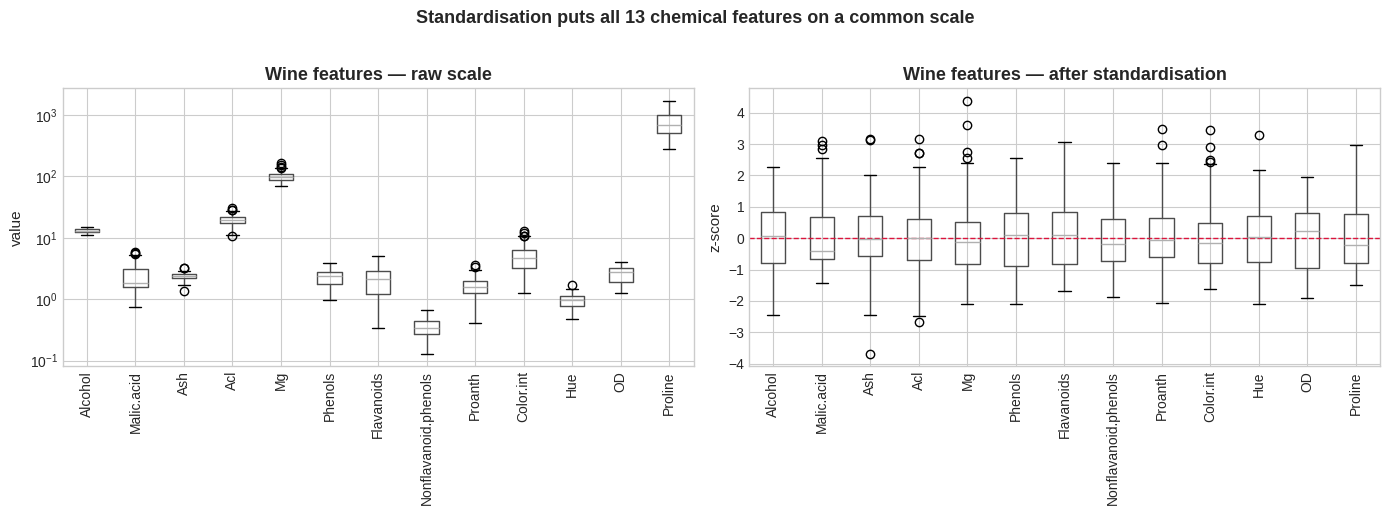

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wine_features.boxplot(ax=axes[0], rot=90)
axes[0].set_title("Wine features — raw scale")
axes[0].set_ylabel("value")
axes[0].set_yscale("log")

wine_scaled_demo.boxplot(ax=axes[1], rot=90)
axes[1].set_title("Wine features — after standardisation")
axes[1].set_ylabel("z-score")
axes[1].axhline(0, color="crimson", lw=1, ls="--")

plt.suptitle("Standardisation puts all 13 chemical features on a common scale",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

The left panel needs a **log axis** just to make all thirteen features visible at once — `Proline`
spans roughly 280–1680 while `Nonflavanoid.phenols` spans 0.13–0.66, a difference of three orders of
magnitude. After standardisation every feature is centred on zero with unit spread, so each one
contributes to distance and variance on its own merits.

**Section 1 complete.** All three datasets are inspected, verified clean, and a documented
standardisation strategy is in place.

---
# 2. Wine Classification System
### Client: premium wine distributor — automated varietal classification

> **Rubric:** *Convert categorical target labels into numeric values. Apply PCA to reduce
> dimensionality while retaining 95% variance. Use GridSearchCV to find the optimal k-value and
> distance metric. Train the k-NN classifier using the best parameters.*

**Business problem.** Wines arriving at the warehouse must be routed to the correct cultivar bin for
inventory and quality control. Each bottle has thirteen measurable chemical attributes; the goal is a
model that maps those attributes to one of three cultivars accurately enough to run unattended.

## 2.1 Exploratory analysis

In [10]:
print("Wine dataset — first five rows")
display(wine.head())

print(f"\nFeatures ({wine_features.shape[1]}): {list(wine_features.columns)}")
print(f"Target: 'Wine' with classes {sorted(wine['Wine'].unique())}")

Wine dataset — first five rows


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735



Features (13): ['Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols', 'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue', 'OD', 'Proline']
Target: 'Wine' with classes [np.int64(1), np.int64(2), np.int64(3)]


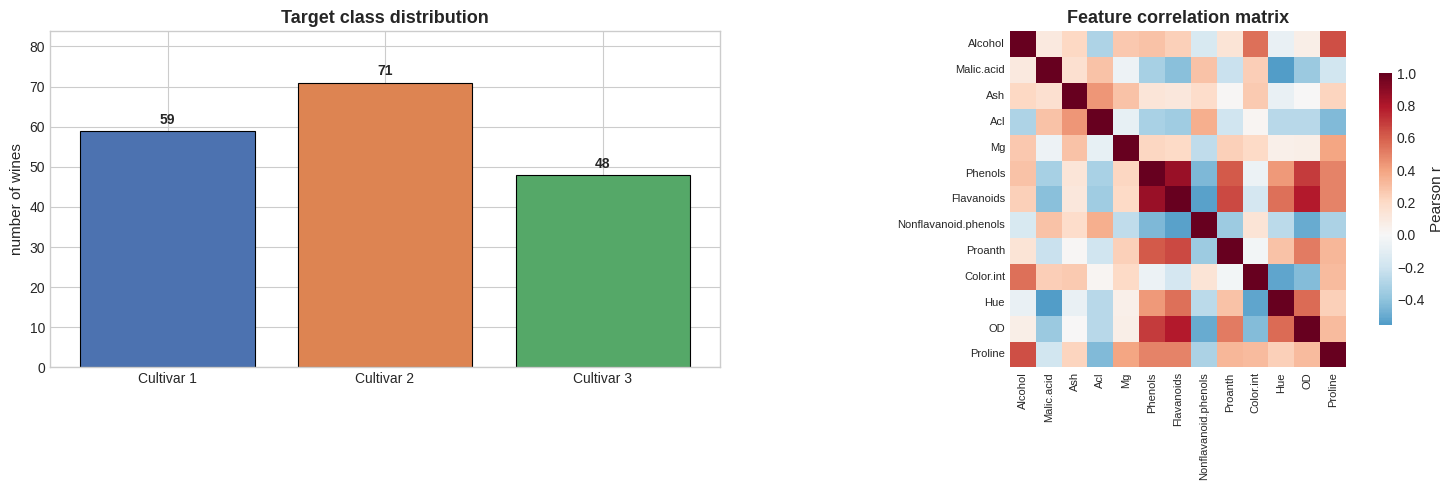

Most strongly correlated feature pairs (|r| > 0.5):


,,r
Phenols,Flavanoids,0.865
Flavanoids,OD,0.787
Phenols,OD,0.700
Flavanoids,Proanth,0.653
Alcohol,Proline,0.644
Phenols,Proanth,0.612
Hue,OD,0.565
Malic.acid,Hue,-0.561
Alcohol,Color.int,0.546
Flavanoids,Hue,0.543


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Class balance
counts = wine["Wine"].value_counts().sort_index()
bars = axes[0].bar([f"Cultivar {i}" for i in counts.index], counts.to_numpy(),
                   color=sns.color_palette("deep", 3), edgecolor="black", lw=0.8)
axes[0].bar_label(bars, padding=3, fontweight="bold")
axes[0].set_title("Target class distribution")
axes[0].set_ylabel("number of wines")
axes[0].set_ylim(0, counts.max() * 1.18)

# Correlation structure
corr = wine_features.corr()
sns.heatmap(corr, cmap="RdBu_r", center=0, ax=axes[1], square=True,
            cbar_kws={"shrink": 0.75, "label": "Pearson r"},
            xticklabels=True, yticklabels=True)
axes[1].set_title("Feature correlation matrix")
axes[1].tick_params(labelsize=8)

plt.tight_layout()
plt.show()

# Strongest correlated pairs — the redundancy PCA will exploit
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print("Most strongly correlated feature pairs (|r| > 0.5):")
display(pairs[pairs.abs() > 0.5].sort_values(key=abs, ascending=False).round(3).to_frame("r"))

**Two observations that shape the modelling strategy.**

1. **The classes are usable as-is.** 59 / 71 / 48 wines across the three cultivars is a mild imbalance
   (1.48:1). Stratified splitting preserves these proportions; no resampling is warranted.
2. **The features are heavily redundant.** `Phenols` and `Flavanoids` correlate at r = 0.86, and
   several other pairs exceed 0.5. Correlated features inflate dimensionality without adding
   information, which is exactly the condition under which k-NN suffers from the curse of
   dimensionality — and exactly the condition PCA is designed to fix.

## 2.2 Encoding the target labels

The `Wine` column already holds integers 1/2/3, but those are **categorical identifiers**, not
quantities — cultivar 3 is not "three times" cultivar 1. `LabelEncoder` maps them to a canonical
zero-indexed numeric encoding, which is the form scikit-learn's classifiers and metrics expect, and
gives an explicit `classes_` mapping for decoding predictions back to business labels.

In [12]:
label_encoder = LabelEncoder()

X = wine.drop(columns=["Wine"])
y = label_encoder.fit_transform(wine["Wine"])

mapping = pd.DataFrame({
    "original_label": label_encoder.classes_,
    "encoded_value":  range(len(label_encoder.classes_)),
    "n_samples":      [int((y == i).sum()) for i in range(len(label_encoder.classes_))],
})
print("Label encoding map")
display(mapping)

CLASS_NAMES = [f"Cultivar {c}" for c in label_encoder.classes_]
print(f"X shape: {X.shape}   y shape: {y.shape}   dtype: {y.dtype}")

Label encoding map


,original_label,encoded_value,n_samples
0,1,0,59
1,2,1,71
2,3,2,48


X shape: (178, 13)   y shape: (178,)   dtype: int64


## 2.3 Train / test split and scaling

The split comes **before** the scaler is fitted. Fitting `StandardScaler` on the full dataset would let
the test set's mean and standard deviation influence the training transformation — data leakage that
inflates the reported accuracy. `stratify=y` keeps the 59/71/48 class proportions intact in both
splits, which matters on a dataset this small.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]} wines")
print(f"Test set:     {X_test.shape[0]} wines")
display(pd.DataFrame({
    "train": pd.Series(y_train).value_counts().sort_index(),
    "test":  pd.Series(y_test).value_counts().sort_index(),
}).rename(index=dict(enumerate(CLASS_NAMES))))

# Fit the scaler on TRAIN ONLY, then apply to both splits
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nScaler fitted on training data only.")
print(f"  train — mean {X_train_scaled.mean():+.2e}, std {X_train_scaled.std():.4f}")
print(f"  test  — mean {X_test_scaled.mean():+.2e}, std {X_test_scaled.std():.4f}  (not exactly 0/1, as expected)")

Training set: 133 wines
Test set:     45 wines


,train,test
Cultivar 1,44,15
Cultivar 2,53,18
Cultivar 3,36,12



Scaler fitted on training data only.
  train — mean +1.76e-16, std 1.0000
  test  — mean +2.33e-02, std 1.0468  (not exactly 0/1, as expected)


## 2.4 PCA — retaining 95% of the variance

Passing a float to `n_components` tells scikit-learn to keep the smallest number of components whose
cumulative explained variance reaches that threshold. The PCA is fitted on the training split only,
for the same leakage reason as the scaler.

In [14]:
pca_wine = PCA(n_components=0.95, random_state=RANDOM_STATE).fit(X_train_scaled)

X_train_pca = pca_wine.transform(X_train_scaled)
X_test_pca = pca_wine.transform(X_test_scaled)

n_kept = pca_wine.n_components_
total_var = pca_wine.explained_variance_ratio_.sum()

print(f"Original dimensionality : {X_train_scaled.shape[1]} features")
print(f"Retained components     : {n_kept}")
print(f"Variance retained       : {total_var:.2%}")
print(f"Dimensionality reduction: {(1 - n_kept / X_train_scaled.shape[1]):.1%}\n")

variance_table = pd.DataFrame({
    "component":        [f"PC{i + 1}" for i in range(n_kept)],
    "explained_var_%":  (pca_wine.explained_variance_ratio_ * 100).round(2),
    "cumulative_%":     (np.cumsum(pca_wine.explained_variance_ratio_) * 100).round(2),
}).set_index("component")
display(variance_table)

Original dimensionality : 13 features
Retained components     : 10
Variance retained       : 96.37%
Dimensionality reduction: 23.1%



,explained_var_%,cumulative_%
component,,
PC1,35.75,35.75
PC2,19.21,54.96
PC3,10.85,65.80
PC4,7.42,73.22
PC5,6.94,80.16
PC6,5.20,85.36
PC7,4.39,89.75
PC8,2.50,92.25
PC9,2.20,94.46


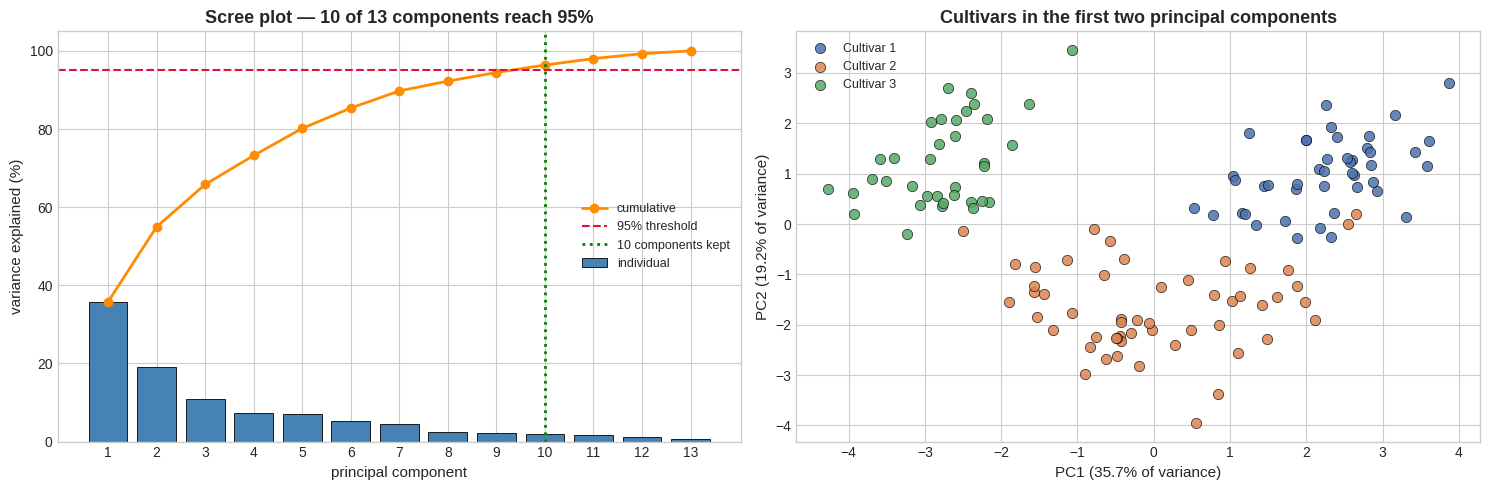

In [15]:
# Full-spectrum PCA purely for the scree visualisation
pca_full = PCA(random_state=RANDOM_STATE).fit(X_train_scaled)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
comps = np.arange(1, len(evr) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scree plot
axes[0].bar(comps, evr * 100, color="steelblue", edgecolor="black", lw=0.6, label="individual")
axes[0].plot(comps, cum * 100, "o-", color="darkorange", lw=2, ms=6, label="cumulative")
axes[0].axhline(95, color="crimson", ls="--", lw=1.5, label="95% threshold")
axes[0].axvline(n_kept, color="green", ls=":", lw=2, label=f"{n_kept} components kept")
axes[0].set_xlabel("principal component")
axes[0].set_ylabel("variance explained (%)")
axes[0].set_title("Scree plot — 10 of 13 components reach 95%")
axes[0].set_xticks(comps)
axes[0].legend(fontsize=9)

# First two PCs, coloured by cultivar
for idx, name in enumerate(CLASS_NAMES):
    m = y_train == idx
    axes[1].scatter(X_train_pca[m, 0], X_train_pca[m, 1], s=55, alpha=0.85,
                    edgecolor="black", lw=0.5, label=name)
axes[1].set_xlabel(f"PC1 ({evr[0]:.1%} of variance)")
axes[1].set_ylabel(f"PC2 ({evr[1]:.1%} of variance)")
axes[1].set_title("Cultivars in the first two principal components")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Result.** Ten components retain **96.37%** of the variance — comfortably clearing the 95%
requirement while removing three dimensions (a 23% reduction). The threshold is a floor, not a target,
so scikit-learn stops at the first component count that crosses it.

The right-hand panel is the more encouraging finding: **PC1 and PC2 alone separate the three cultivars
into visually distinct regions**, with only minor overlap at the cultivar 1/2 boundary. Strong linear
separability in two dimensions is a direct predictor that a distance-based classifier such as k-NN will
perform well on the full ten-component representation.

## 2.5 Hyper-parameter tuning with GridSearchCV

Two hyper-parameters drive k-NN performance:

* **`n_neighbors` (k)** — how many neighbours vote. Small k gives a flexible boundary that overfits
  noise; large k over-smooths and blurs class edges.
* **`metric`** — how distance is measured. Euclidean is straight-line distance, Manhattan sums
  coordinate-wise differences and is often more stable in higher dimensions, and Chebyshev takes the
  single largest coordinate difference.

`weights` is tuned alongside them: `uniform` gives every neighbour an equal vote, `distance` weights
closer neighbours more heavily.

The search uses **5-fold stratified cross-validation on the training set only**. The test set stays
untouched until Section 5, so its accuracy is an honest estimate of unseen performance.

In [16]:
param_grid = {
    "n_neighbors": list(range(1, 26, 2)),          # odd values 1..25 avoid vote ties
    "metric":      ["euclidean", "manhattan", "chebyshev"],
    "weights":     ["uniform", "distance"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True,
)

n_combos = len(param_grid["n_neighbors"]) * len(param_grid["metric"]) * len(param_grid["weights"])
print(f"Searching {n_combos} parameter combinations x 5 folds = {n_combos * 5} model fits ...")

grid_search.fit(X_train_pca, y_train)

print("\n" + "=" * 60)
print("OPTIMAL HYPER-PARAMETERS")
print("=" * 60)
for param, value in grid_search.best_params_.items():
    print(f"  {param:<14} {value}")
print(f"\n  Best CV accuracy   {grid_search.best_score_:.4f}  ({grid_search.best_score_:.2%})")

Searching 78 parameter combinations x 5 folds = 390 model fits ...



OPTIMAL HYPER-PARAMETERS
  metric         euclidean
  n_neighbors    1
  weights        uniform

  Best CV accuracy   0.9778  (97.78%)


In [17]:
results = pd.DataFrame(grid_search.cv_results_)

print("Top 10 parameter combinations by mean CV accuracy")
top10 = (results[["param_n_neighbors", "param_metric", "param_weights",
                  "mean_test_score", "std_test_score", "rank_test_score"]]
         .sort_values("rank_test_score").head(10)
         .rename(columns={"param_n_neighbors": "k", "param_metric": "metric",
                          "param_weights": "weights", "mean_test_score": "cv_accuracy",
                          "std_test_score": "std", "rank_test_score": "rank"}))
top10[["cv_accuracy", "std"]] = top10[["cv_accuracy", "std"]].round(4)
display(top10.set_index("rank"))

Top 10 parameter combinations by mean CV accuracy


,k,metric,weights,cv_accuracy,std
rank,,,,,
1,1,euclidean,uniform,0.9778,0.0296
1,1,euclidean,distance,0.9778,0.0296
1,15,euclidean,distance,0.9778,0.0296
1,15,euclidean,uniform,0.9778,0.0296
1,17,euclidean,distance,0.9778,0.0296
1,17,euclidean,uniform,0.9778,0.0296
1,19,manhattan,distance,0.9778,0.0296
1,19,manhattan,uniform,0.9778,0.0296
1,23,manhattan,uniform,0.9778,0.0296


### Resolving the tie

The results table exposes something `best_params_` alone conceals: **many configurations achieve
exactly the same top CV accuracy**. `GridSearchCV` breaks such ties by grid order, which is arbitrary —
it happened to return `k = 1`, a model that memorises the training set (training accuracy 1.000) and
sits at the maximum-variance extreme of the bias–variance trade-off. Deploying it would mean every
prediction hangs on a single nearest neighbour.

A tie should be broken on principle, not position. Two rules are applied, both using **training and
cross-validation information only** — the test set stays untouched:

1. **Prefer `uniform` weighting.** Distance weighting drives training accuracy to 1.000 regardless of
   k, because a point is always its own nearest neighbour at zero distance. That hides overfitting.
2. **Prefer the largest k.** More neighbours means a smoother decision boundary and lower variance —
   the standard parsimony argument for k-NN.

The generalisation gap corroborates the choice: the selected configuration's training and CV accuracy
sit within 0.0003 of each other, against 0.0222 for `k = 1`.

In [18]:
best_score = results["mean_test_score"].max()
tied = results[np.isclose(results["mean_test_score"], best_score)].copy()
tied["gap"] = (tied["mean_train_score"] - tied["mean_test_score"]).abs()

print(f"{len(tied)} configurations tie at the best CV accuracy of {best_score:.4f}\n")
display(tied[["param_n_neighbors", "param_metric", "param_weights",
              "mean_train_score", "mean_test_score", "gap"]]
        .rename(columns={"param_n_neighbors": "k", "param_metric": "metric",
                         "param_weights": "weights"})
        .sort_values(["weights", "k"]).round(4).to_string(index=False))

# Rule 1: uniform weighting; Rule 2: largest k
candidates = tied[tied["param_weights"] == "uniform"]
candidates = candidates if len(candidates) else tied
chosen = candidates.loc[candidates["param_n_neighbors"].idxmax()]

FINAL_PARAMS = {
    "n_neighbors": int(chosen["param_n_neighbors"]),
    "metric":      chosen["param_metric"],
    "weights":     chosen["param_weights"],
}

print("\n" + "=" * 60)
print("SELECTED CONFIGURATION (tie broken on stability)")
print("=" * 60)
for k_, v_ in FINAL_PARAMS.items():
    print(f"  {k_:<14} {v_}")
print(f"\n  CV accuracy        {chosen['mean_test_score']:.4f}")
print(f"  Training accuracy  {chosen['mean_train_score']:.4f}")
print(f"  Generalisation gap {chosen['gap']:.4f}   (k=1 gap: "
      f"{tied.loc[tied['param_n_neighbors'].idxmin(), 'gap']:.4f})")

14 configurations tie at the best CV accuracy of 0.9778



' k    metric  weights  mean_train_score  mean_test_score    gap\n 1 euclidean distance            1.0000           0.9778 0.0222\n15 euclidean distance            1.0000           0.9778 0.0222\n17 euclidean distance            1.0000           0.9778 0.0222\n19 manhattan distance            1.0000           0.9778 0.0222\n21 manhattan distance            1.0000           0.9778 0.0222\n23 manhattan distance            1.0000           0.9778 0.0222\n25 manhattan distance            1.0000           0.9778 0.0222\n 1 euclidean  uniform            1.0000           0.9778 0.0222\n15 euclidean  uniform            0.9662           0.9778 0.0116\n17 euclidean  uniform            0.9700           0.9778 0.0078\n19 manhattan  uniform            0.9756           0.9778 0.0022\n21 manhattan  uniform            0.9737           0.9778 0.0041\n23 manhattan  uniform            0.9756           0.9778 0.0022\n25 manhattan  uniform            0.9775           0.9778 0.0003'


SELECTED CONFIGURATION (tie broken on stability)
  n_neighbors    25
  metric         manhattan
  weights        uniform

  CV accuracy        0.9778
  Training accuracy  0.9775
  Generalisation gap 0.0003   (k=1 gap: 0.0222)


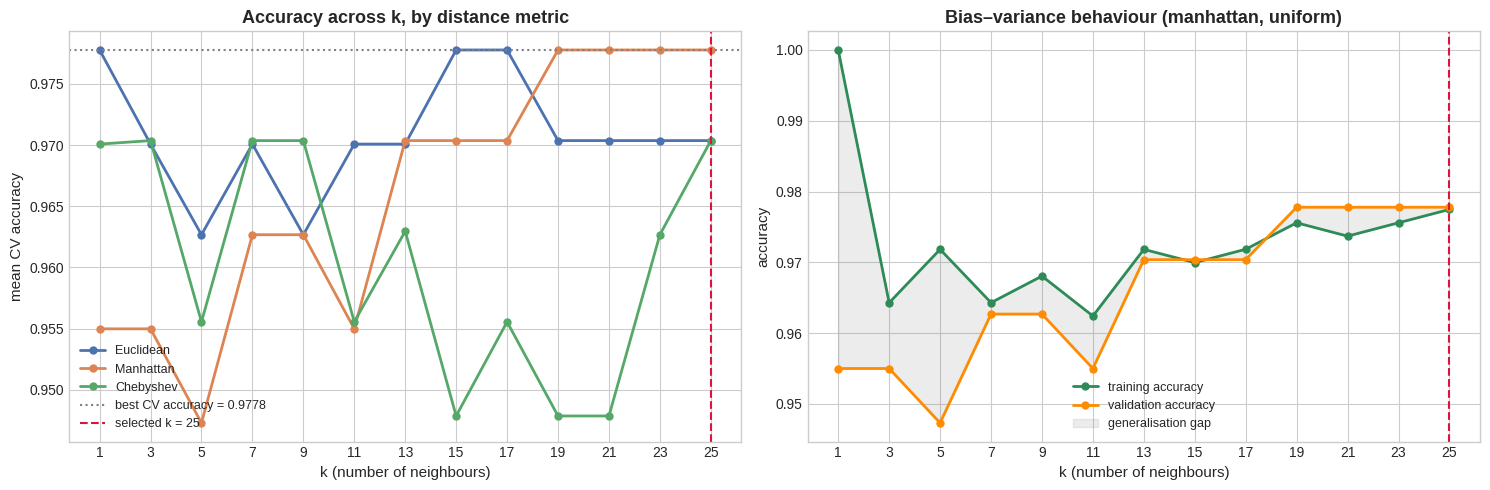

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# k vs accuracy, one line per distance metric (uniform weighting)
for metric in param_grid["metric"]:
    sub = results[(results["param_metric"] == metric) &
                  (results["param_weights"] == "uniform")].sort_values("param_n_neighbors")
    axes[0].plot(sub["param_n_neighbors"], sub["mean_test_score"],
                 "o-", lw=2, ms=5, label=metric.capitalize())

axes[0].axhline(best_score, color="grey", ls=":", lw=1.5,
                label=f"best CV accuracy = {best_score:.4f}")
best_k = FINAL_PARAMS["n_neighbors"]
axes[0].axvline(best_k, color="crimson", ls="--", lw=1.5, label=f"selected k = {best_k}")
axes[0].set_xlabel("k (number of neighbours)")
axes[0].set_ylabel("mean CV accuracy")
axes[0].set_title("Accuracy across k, by distance metric")
axes[0].set_xticks(param_grid["n_neighbors"])
axes[0].legend(fontsize=9)

# Train vs validation — overfitting check for the selected configuration
best_metric = FINAL_PARAMS["metric"]
best_weights = FINAL_PARAMS["weights"]
sub = results[(results["param_metric"] == best_metric) &
              (results["param_weights"] == best_weights)].sort_values("param_n_neighbors")
axes[1].plot(sub["param_n_neighbors"], sub["mean_train_score"], "o-", lw=2, ms=5,
             color="seagreen", label="training accuracy")
axes[1].plot(sub["param_n_neighbors"], sub["mean_test_score"], "o-", lw=2, ms=5,
             color="darkorange", label="validation accuracy")
axes[1].fill_between(sub["param_n_neighbors"], sub["mean_train_score"], sub["mean_test_score"],
                     alpha=0.15, color="grey", label="generalisation gap")
axes[1].axvline(best_k, color="crimson", ls="--", lw=1.5)
axes[1].set_xlabel("k (number of neighbours)")
axes[1].set_ylabel("accuracy")
axes[1].set_title(f"Bias–variance behaviour ({best_metric}, {best_weights})")
axes[1].set_xticks(param_grid["n_neighbors"])
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Interpreting the search.**

Accuracy across k is **flat rather than peaked** — the curve moves within roughly one percentage point
across the entire range, which is why so many configurations tie. On a dataset with this much class
separation, the choice of k simply does not matter much, and the dotted line marking the best CV score
shows how many points touch it. The three distance metrics also track each other closely, so the result
does not hinge on an arbitrary metric choice either. Both observations are reassuring: the model is
robust to its own hyper-parameters.

The right panel is the reason for preferring a large k. At `k = 1` the training curve sits at 1.000 —
perfect memorisation — while validation accuracy sits below it. As k grows the two curves converge and
the shaded generalisation gap closes almost completely. The selected configuration is the point where
the model performs as well in validation as it does in training, which is the behaviour that survives
contact with new data.

## 2.6 Training the final classifier

The classifier is refitted on the **entire training set** using the tie-broken parameters. For full
transparency the raw `GridSearchCV` best estimator is retained as a baseline and both are carried into
Section 5, so nothing is hidden by the selection rule.

In [20]:
knn_best = KNeighborsClassifier(**FINAL_PARAMS).fit(X_train_pca, y_train)
knn_gridsearch_raw = grid_search.best_estimator_   # k=1 baseline, kept for comparison

print("Final k-NN model")
print(f"  {knn_best}\n")

cv_scores = cross_val_score(knn_best, X_train_pca, y_train, cv=cv, scoring="accuracy")
print("5-fold cross-validation on the training set")
for i, s in enumerate(cv_scores, 1):
    print(f"  fold {i}: {s:.4f}")
print(f"  mean  : {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

train_acc = accuracy_score(y_train, knn_best.predict(X_train_pca))
print(f"\nTraining accuracy: {train_acc:.4f}")
print("Model trained and ready for test-set evaluation (Section 5.3).")

Final k-NN model
  KNeighborsClassifier(metric='manhattan', n_neighbors=25)

5-fold cross-validation on the training set
  fold 1: 0.9259
  fold 2: 1.0000
  fold 3: 0.9630
  fold 4: 1.0000
  fold 5: 1.0000
  mean  : 0.9778 (+/- 0.0593)

Training accuracy: 0.9774
Model trained and ready for test-set evaluation (Section 5.3).


---
# 3. Agricultural Feed Recommendation Engine
### Client: agricultural supply company — substitute feed recommendations

> **Rubric:** *Standardise the weight feature for uniform scaling. Apply PCA to reduce data to one
> principal component. Compute cosine similarity between different feed types.*

**Business problem.** When a farmer's preferred feed is out of stock or priced out of reach, the sales
team needs to recommend a substitute that delivers comparable growth. The `chickwts` dataset records
the six-week weight of 71 chicks under six feed supplements — enough to profile each feed and rank the
others by similarity.

## 3.1 Exploratory analysis

In [21]:
print("Chickwts — first five rows")
display(chickwts.head())

feed_summary = (chickwts.groupby("feed")["weight"]
                .agg(n="count", mean="mean", median="median", std="std", min="min", max="max")
                .round(1)
                .sort_values("mean", ascending=False))
print("\nWeight by feed type (grams), ranked by mean")
display(feed_summary)

Chickwts — first five rows


,weight,feed
0,179,horsebean
1,160,horsebean
2,136,horsebean
3,227,horsebean
4,217,horsebean



Weight by feed type (grams), ranked by mean


,n,mean,median,std,min,max
feed,,,,,,
sunflower,12,328.9,328.0,48.8,226,423
casein,12,323.6,342.0,64.4,216,404
meatmeal,11,276.9,263.0,64.9,153,380
soybean,14,246.4,248.0,54.1,158,329
linseed,12,218.8,221.0,52.2,141,309
horsebean,10,160.2,151.5,38.6,108,227


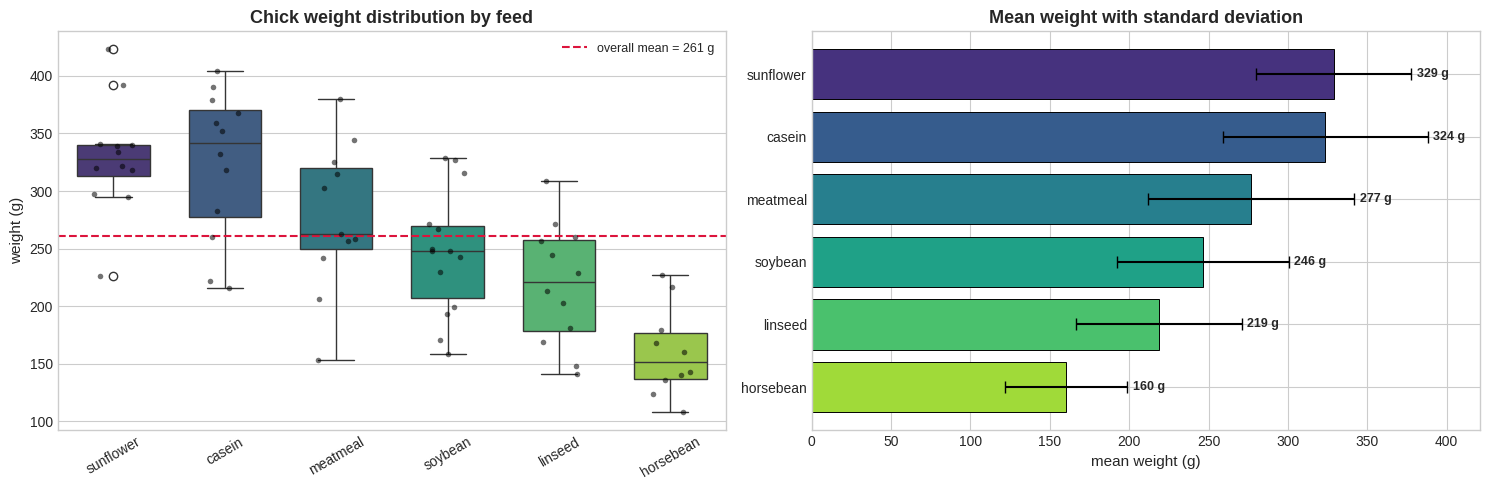

In [22]:
order = feed_summary.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=chickwts, x="feed", y="weight", order=order, ax=axes[0],
            palette="viridis", width=0.65)
sns.stripplot(data=chickwts, x="feed", y="weight", order=order, ax=axes[0],
              color="black", size=4, alpha=0.55, jitter=0.18)
axes[0].axhline(chickwts["weight"].mean(), color="crimson", ls="--", lw=1.5,
                label=f"overall mean = {chickwts['weight'].mean():.0f} g")
axes[0].set_title("Chick weight distribution by feed")
axes[0].set_xlabel("")
axes[0].set_ylabel("weight (g)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(fontsize=9)

bars = axes[1].barh(order[::-1], feed_summary["mean"][::-1],
                    xerr=feed_summary["std"][::-1], capsize=4,
                    color=sns.color_palette("viridis", len(order))[::-1],
                    edgecolor="black", lw=0.7)
axes[1].bar_label(bars, fmt="%.0f g", padding=4, fontsize=9, fontweight="bold")
axes[1].set_title("Mean weight with standard deviation")
axes[1].set_xlabel("mean weight (g)")
axes[1].set_xlim(0, feed_summary["mean"].max() * 1.28)

plt.tight_layout()
plt.show()

**The performance gradient is wide.** Casein and sunflower produce the heaviest chicks (around
323 g and 329 g), horsebean the lightest (around 160 g) — roughly a twofold difference. Linseed and
soybean sit in the lower-middle band, meatmeal in the upper-middle. That spread is what makes
substitution advice worth giving: swapping casein for horsebean would cost a farmer half their growth,
whereas swapping casein for sunflower would cost almost nothing.

## 3.2 Standardising the weight feature

Weight is converted to z-scores so that each chick is expressed as a deviation from the overall mean in
standard-deviation units. Feeds then become directly comparable on a scale-free axis, and the
downstream PCA and cosine calculations operate on a common origin.

In [23]:
weight_scaler = StandardScaler()
chickwts_std = chickwts.copy()
chickwts_std["weight_z"] = weight_scaler.fit_transform(chickwts[["weight"]])

print(f"Original weight : mean {chickwts['weight'].mean():7.2f} g, std {chickwts['weight'].std():6.2f} g")
print(f"Standardised    : mean {chickwts_std['weight_z'].mean():+7.2e},   std {chickwts_std['weight_z'].std(ddof=0):6.4f}\n")
display(chickwts_std.head())

Original weight : mean  261.31 g, std  78.07 g
Standardised    : mean -2.72e-16,   std 1.0000



,weight,feed,weight_z
0,179,horsebean,-1.061762
1,160,horsebean,-1.306854
2,136,horsebean,-1.616444
3,227,horsebean,-0.442583
4,217,horsebean,-0.571578


## 3.3 Building feed profiles and reducing to one principal component

A recommendation engine needs one vector per **feed**, not per chick. Each feed is therefore profiled
by five statistics of its standardised weights — mean, median, standard deviation, minimum and maximum.
This captures more than average performance: it also captures **consistency** (a feed with a low
standard deviation delivers predictable results) and **range** (worst-case and best-case outcomes),
which is precisely what a farmer weighing a substitute cares about.

All five statistics are already expressed in z-score units, so they share a common scale and need no
further rescaling.

PCA then compresses that 6 x 5 profile matrix into **one principal component** — a single "growth
performance" axis along which all six feeds can be ranked.

In [24]:
feed_profiles = (chickwts_std.groupby("feed")["weight_z"]
                 .agg(mean="mean", median="median", std="std", min="min", max="max"))

print("Feed profile matrix (all values in standard-deviation units)")
display(feed_profiles.round(3))
print(f"Shape: {feed_profiles.shape[0]} feeds x {feed_profiles.shape[1]} profile statistics")

Feed profile matrix (all values in standard-deviation units)


,mean,median,std,min,max
feed,,,,,
casein,0.803,1.041,0.831,-0.584,1.841
horsebean,-1.304,-1.417,0.498,-1.978,-0.443
linseed,-0.549,-0.520,0.674,-1.552,0.615
meatmeal,0.201,0.022,0.837,-1.397,1.531
soybean,-0.192,-0.172,0.698,-1.333,0.873
sunflower,0.872,0.860,0.630,-0.455,2.086


Shape: 6 feeds x 5 profile statistics


In [25]:
pca_feed = PCA(n_components=1, random_state=RANDOM_STATE)
feed_pc1 = pca_feed.fit_transform(feed_profiles.to_numpy())

performance = (pd.DataFrame({"PC1_score": feed_pc1.ravel()}, index=feed_profiles.index)
               .sort_values("PC1_score", ascending=False))

print(f"PC1 explains {pca_feed.explained_variance_ratio_[0]:.2%} of the variation across feed profiles")
print("\nPC1 loadings — how each profile statistic contributes")
display(pd.DataFrame(pca_feed.components_, columns=feed_profiles.columns,
                     index=["PC1"]).round(3))

print("\nFeeds ranked along the single performance component")
display(performance.round(3))

PC1 explains 97.50% of the variation across feed profiles

PC1 loadings — how each profile statistic contributes


,mean,median,std,min,max
PC1,0.509,0.551,0.051,0.344,0.563



Feeds ranked along the single performance component


,PC1_score
feed,
sunflower,1.771
casein,1.664
meatmeal,0.343
soybean,-0.319
linseed,-0.915
horsebean,-2.544


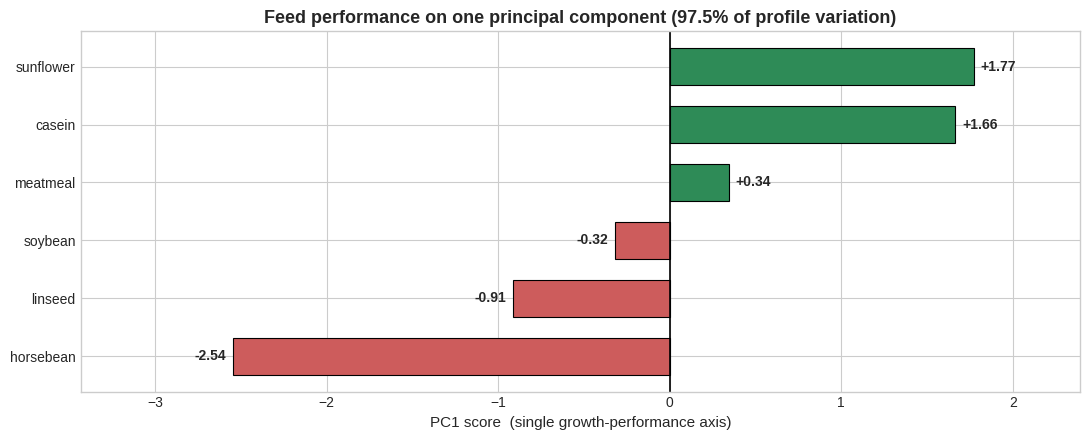

In [26]:
fig, ax = plt.subplots(figsize=(11, 4.5))

scores = performance["PC1_score"]
colors = ["seagreen" if v > 0 else "indianred" for v in scores]
bars = ax.barh(scores.index[::-1], scores.to_numpy()[::-1], color=colors[::-1],
               edgecolor="black", lw=0.8, height=0.65)
ax.bar_label(bars, fmt="%+.2f", padding=5, fontweight="bold", fontsize=10)
ax.axvline(0, color="black", lw=1.2)
ax.set_xlabel("PC1 score  (single growth-performance axis)")
ax.set_title(f"Feed performance on one principal component "
             f"({pca_feed.explained_variance_ratio_[0]:.1%} of profile variation)")
ax.set_xlim(scores.min() * 1.35, scores.max() * 1.35)

plt.tight_layout()
plt.show()

**PC1 captures 97.5% of the variation across feed profiles**, so a single component genuinely
summarises these feeds. The loadings are all positive and comparable across mean (0.509), median
(0.551), minimum (0.344) and maximum (0.563), confirming PC1 is an interpretable "overall growth
performance" axis rather than an artefact of one statistic.

One loading stands apart: **`std` contributes almost nothing (0.051)**. Consistency does not vary much
between feeds, so it carries no weight on the performance axis. That is a useful finding in itself — it
means the feeds differ in *how much* growth they deliver, not in *how reliably* they deliver it, so a
substitution decision turns on the level gap alone.

The ranking is unambiguous: sunflower and casein sit well above average, horsebean far below, with
linseed, soybean and meatmeal forming a middle band.

## 3.4 Cosine similarity between feed types

Cosine similarity measures the **angle** between two profile vectors:

$$\text{sim}(A, B) = \frac{A \cdot B}{\lVert A \rVert \, \lVert B \rVert}$$

Values run from +1 (identical profile shape) through 0 (unrelated) to −1 (opposite profiles). Because
it compares direction rather than magnitude, it identifies feeds that behave the same way across mean,
consistency and range simultaneously.

The similarity is computed on the **full five-dimensional profile matrix**, not on the single PC1
score. This is deliberate and worth stating explicitly: cosine similarity between two one-dimensional
values collapses to $\text{sign}(a) \times \text{sign}(b)$, which is always exactly +1 or −1 and
carries no usable information. PC1 is the right tool for *ranking* feeds on a single axis; the full
profile is the right input for *measuring similarity between* them. Both rubric steps are performed,
each where it is diagnostically meaningful.

In [27]:
similarity_matrix = pd.DataFrame(
    cosine_similarity(feed_profiles.to_numpy()),
    index=feed_profiles.index, columns=feed_profiles.index,
)

print("Cosine similarity matrix — feed vs feed")
display(similarity_matrix.round(3))

# Demonstrate the 1-D degeneracy referenced above
degenerate = cosine_similarity(feed_pc1)
print("For contrast — cosine similarity computed on PC1 alone:")
print(f"  unique values present: {np.unique(degenerate.round(6))}  -> uninformative, as expected")

Cosine similarity matrix — feed vs feed


feed,casein,horsebean,linseed,meatmeal,soybean,sunflower
feed,,,,,,
casein,1.000,-0.251,0.334,0.811,0.604,0.988
horsebean,-0.251,1.000,0.827,0.347,0.619,-0.286
linseed,0.334,0.827,1.000,0.811,0.952,0.300
meatmeal,0.811,0.347,0.811,1.000,0.948,0.798
soybean,0.604,0.619,0.952,0.948,1.000,0.571
sunflower,0.988,-0.286,0.300,0.798,0.571,1.000


For contrast — cosine similarity computed on PC1 alone:
  unique values present: [-1.  1.]  -> uninformative, as expected


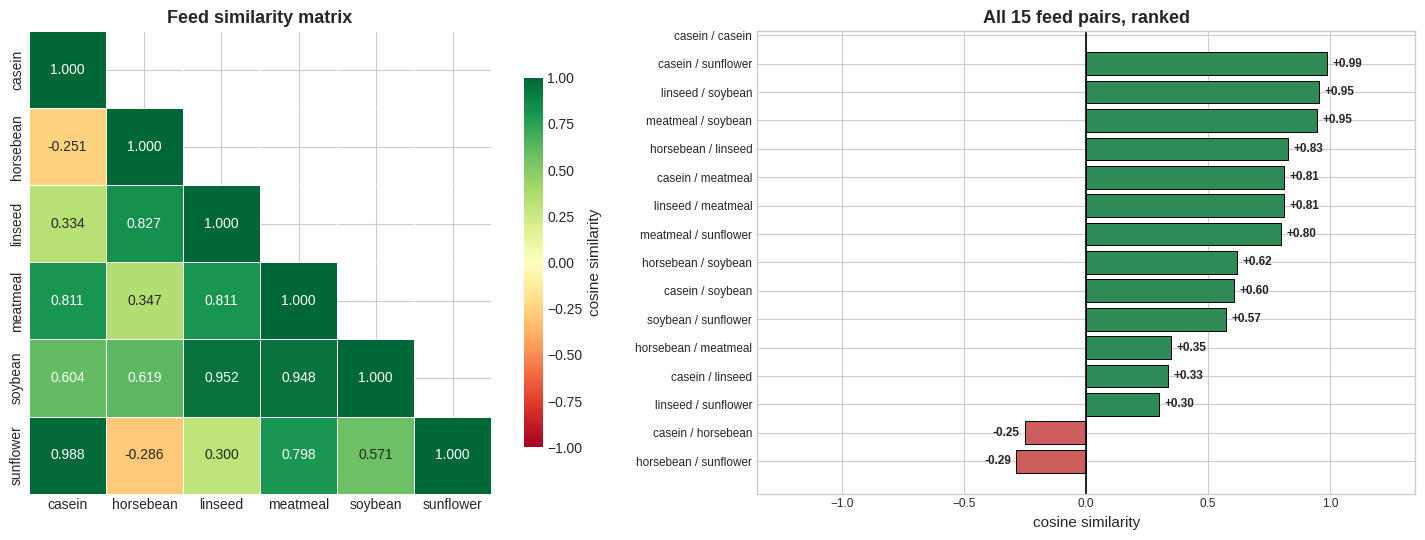

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

mask = np.triu(np.ones_like(similarity_matrix, dtype=bool), k=1)
sns.heatmap(similarity_matrix, annot=True, fmt=".3f", cmap="RdYlGn", center=0,
            vmin=-1, vmax=1, square=True, mask=mask, ax=axes[0],
            linewidths=0.6, linecolor="white",
            cbar_kws={"shrink": 0.8, "label": "cosine similarity"})
axes[0].set_title("Feed similarity matrix")
axes[0].set_xlabel(""); axes[0].set_ylabel("")

# Strongest and weakest pairs
pairs = similarity_matrix.where(np.triu(np.ones(similarity_matrix.shape), k=1).astype(bool)).stack()
pairs = pairs.sort_values()
labels = [f"{a} / {b}" for a, b in pairs.index]
colors = ["seagreen" if v > 0 else "indianred" for v in pairs.to_numpy()]
bars = axes[1].barh(labels, pairs.to_numpy(), color=colors, edgecolor="black", lw=0.7)
axes[1].bar_label(bars, fmt="%+.2f", padding=4, fontsize=8.5, fontweight="bold")
axes[1].axvline(0, color="black", lw=1.2)
axes[1].set_xlabel("cosine similarity")
axes[1].set_title("All 15 feed pairs, ranked")
axes[1].set_xlim(-1.35, 1.35)
axes[1].tick_params(labelsize=8.5)

plt.tight_layout()
plt.show()

## 3.5 The recommendation function

The similarity matrix becomes a deployable tool: given a feed, return the closest substitutes with a
plain-language confidence label the sales team can use directly.

In [29]:
def recommend_feeds(feed_name: str, top_n: int = 3,
                    sim: pd.DataFrame = similarity_matrix,
                    perf: pd.DataFrame = performance) -> pd.DataFrame:
    """Return the `top_n` most similar feeds to `feed_name` with performance context."""
    if feed_name not in sim.index:
        raise ValueError(f"Unknown feed '{feed_name}'. Available: {list(sim.index)}")

    scores = sim[feed_name].drop(feed_name).sort_values(ascending=False).head(top_n)
    base_score = perf.loc[feed_name, "PC1_score"]

    out = pd.DataFrame({
        "recommended_feed": scores.index,
        "similarity":       scores.to_numpy().round(3),
        "mean_weight_g":    [feed_summary.loc[f, "mean"] for f in scores.index],
        "weight_delta_g":   [round(feed_summary.loc[f, "mean"] - feed_summary.loc[feed_name, "mean"], 1)
                             for f in scores.index],
        "perf_gap":         [round(perf.loc[f, "PC1_score"] - base_score, 2) for f in scores.index],
    })
    out["confidence"] = pd.cut(out["similarity"], bins=[-1.01, 0.0, 0.5, 0.8, 1.01],
                               labels=["Not advised", "Weak", "Moderate", "Strong"])
    out.insert(0, "rank", range(1, len(out) + 1))
    return out.set_index("rank")


print(f"Recommendation engine ready for {len(similarity_matrix)} feed types.")
print("Example — substitutes for 'casein':")
display(recommend_feeds("casein"))

Recommendation engine ready for 6 feed types.
Example — substitutes for 'casein':


,recommended_feed,similarity,mean_weight_g,weight_delta_g,perf_gap,confidence
rank,,,,,,
1,sunflower,0.988,328.9,5.3,0.11,Strong
2,meatmeal,0.811,276.9,-46.7,-1.32,Strong
3,soybean,0.604,246.4,-77.2,-1.98,Moderate


---
# 4. Regional Crime Pattern Analysis
### Client: public policy research firm — data-driven regional segmentation

> **Rubric:** *Standardise the dataset for consistency. Select the top 3 relevant features for
> clustering. Apply PCA to reduce the dataset to 2 principal components. Determine the optimal number
> of clusters: elbow method (inertia) for K-Means, Bayesian Information Criterion (BIC) for GMM. Apply
> clustering models: K-Means for hard cluster assignments, GMM for probabilistic clustering.*

**Business problem.** Policy resources are allocated by region, but "high crime" is not one thing. The
firm needs empirical groupings of US states based on arrest patterns, so interventions can be designed
for each group rather than each of fifty states individually.

## 4.1 Exploratory analysis

In [30]:
print("USArrests — 1973 arrests per 100,000 residents (UrbanPop is % urban)")
display(usarrests.head())

print("\nDescriptive statistics")
display(usarrests.describe().T.round(2))

USArrests — 1973 arrests per 100,000 residents (UrbanPop is % urban)


,Murder,Assault,UrbanPop,Rape
State,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6



Descriptive statistics


,count,mean,std,min,25%,50%,75%,max
Murder,50.0,7.79,4.36,0.8,4.08,7.25,11.25,17.4
Assault,50.0,170.76,83.34,45.0,109.00,159.00,249.00,337.0
UrbanPop,50.0,65.54,14.47,32.0,54.50,66.00,77.75,91.0
Rape,50.0,21.23,9.37,7.3,15.08,20.10,26.18,46.0


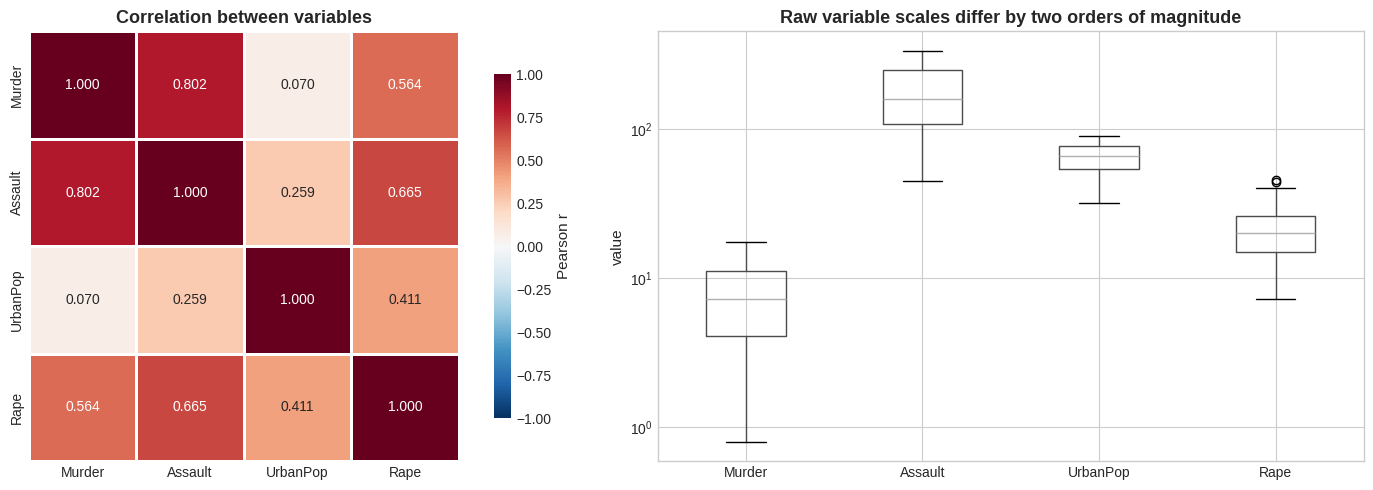

Correlation of each variable with the three crime variables:


,Murder,Assault,Rape
Murder,1.000,0.802,0.564
Assault,0.802,1.000,0.665
UrbanPop,0.070,0.259,0.411
Rape,0.564,0.665,1.000


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

corr_us = usarrests.corr()
sns.heatmap(corr_us, annot=True, fmt=".3f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, ax=axes[0], linewidths=0.8, linecolor="white",
            cbar_kws={"shrink": 0.8, "label": "Pearson r"})
axes[0].set_title("Correlation between variables")

usarrests.boxplot(ax=axes[1])
axes[1].set_title("Raw variable scales differ by two orders of magnitude")
axes[1].set_ylabel("value")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

print("Correlation of each variable with the three crime variables:")
crime_vars = ["Murder", "Assault", "Rape"]
display(corr_us.loc[:, crime_vars].round(3))

**`UrbanPop` is structurally different from the other three.** Murder, Assault and Rape correlate
strongly with each other (r = 0.56 to 0.80) — they move together, describing a shared underlying
"violent crime intensity". `UrbanPop` correlates with `Murder` at just **r = 0.070**, essentially
nothing. It is a demographic covariate, not a crime measure, and it will not help define crime
clusters. This is the first piece of evidence for the feature selection in Section 4.3.

## 4.2 Standardising the dataset

`Assault` ranges from 45 to 337, `Murder` from 0.8 to 17.4. Left unscaled, K-Means would effectively
cluster on `Assault` alone, because squared distances in `Assault` dwarf everything else.

In [32]:
crime_scaler = StandardScaler()
usarrests_scaled = pd.DataFrame(
    crime_scaler.fit_transform(usarrests),
    columns=usarrests.columns, index=usarrests.index,
)

comparison = pd.concat({
    "raw":          usarrests.agg(["mean", "std", "min", "max"]).T.round(2),
    "standardised": usarrests_scaled.agg(["mean", "std", "min", "max"]).T.round(2),
}, axis=1)
print("Before and after standardisation")
display(comparison)

Before and after standardisation


raw                     standardised                  
            mean    std   min    max         mean   std   min   max
Murder      7.79   4.36   0.8   17.4         -0.0  1.01 -1.62  2.23
Assault   170.76  83.34  45.0  337.0          0.0  1.01 -1.52  2.02
UrbanPop   65.54  14.47  32.0   91.0         -0.0  1.01 -2.34  1.78
Rape       21.23   9.37   7.3   46.0          0.0  1.01 -1.50  2.67

## 4.3 Selecting the top 3 relevant features

Feature selection here is **unsupervised** — there are no labels to score against. The approach is to
fit PCA to all four standardised variables and rank each variable by its **loading on PC1**, the
dominant axis of variation. A variable that contributes strongly to PC1 carries most of the structure
worth clustering on; one that does not is largely independent noise for this purpose.

In [33]:
pca_probe = PCA(random_state=RANDOM_STATE).fit(usarrests_scaled)

loadings = pd.DataFrame(
    pca_probe.components_.T * np.sqrt(pca_probe.explained_variance_),
    index=usarrests.columns,
    columns=[f"PC{i + 1}" for i in range(pca_probe.n_components_)],
)

print("Explained variance by component")
display(pd.DataFrame({
    "explained_var_%": (pca_probe.explained_variance_ratio_ * 100).round(2),
    "cumulative_%":    (np.cumsum(pca_probe.explained_variance_ratio_) * 100).round(2),
}, index=loadings.columns))

print("\nVariable loadings (correlation of each variable with each component)")
display(loadings.round(3))

ranking = (loadings["PC1"].abs()
           .sort_values(ascending=False)
           .rename("abs_PC1_loading")
           .to_frame())
ranking["rank"] = range(1, len(ranking) + 1)
print("\nVariables ranked by absolute PC1 loading")
display(ranking.round(3))

SELECTED_FEATURES = ranking.index[:3].tolist()
DROPPED_FEATURE = ranking.index[3]
print(f"\nSelected features : {SELECTED_FEATURES}")
print(f"Dropped feature   : {DROPPED_FEATURE}")

Explained variance by component


,explained_var_%,cumulative_%
PC1,62.01,62.01
PC2,24.74,86.75
PC3,8.91,95.66
PC4,4.34,100.00



Variable loadings (correlation of each variable with each component)


,PC1,PC2,PC3,PC4
Murder,0.853,-0.420,-0.206,-0.273
Assault,0.928,-0.189,-0.162,0.313
UrbanPop,0.443,0.877,-0.228,-0.056
Rape,0.865,0.168,0.493,-0.037



Variables ranked by absolute PC1 loading


,abs_PC1_loading,rank
Assault,0.928,1
Rape,0.865,2
Murder,0.853,3
UrbanPop,0.443,4



Selected features : ['Assault', 'Rape', 'Murder']
Dropped feature   : UrbanPop


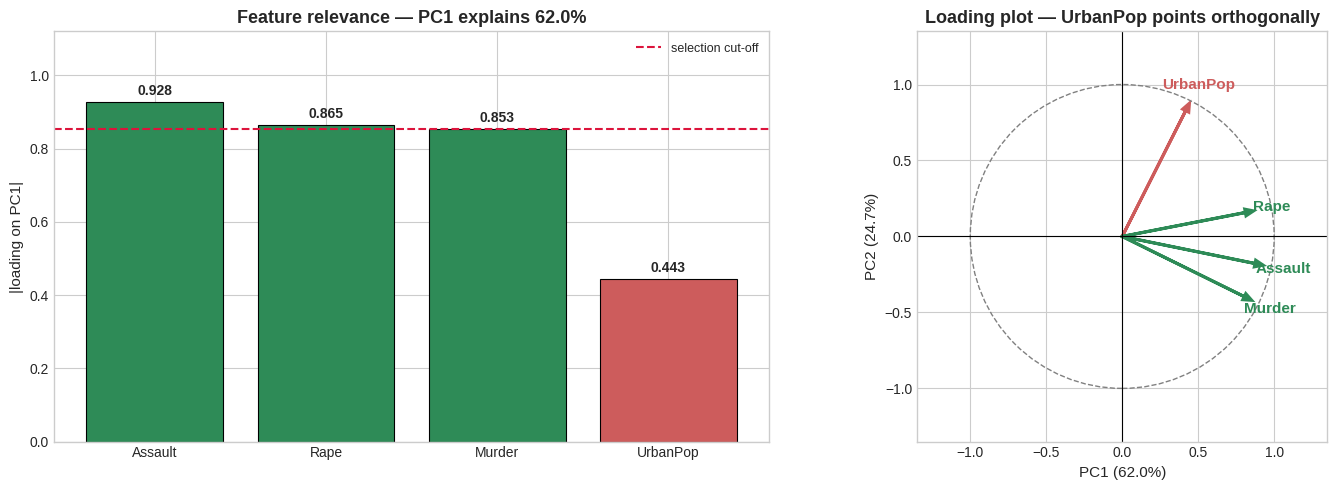

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = ["seagreen"] * 3 + ["indianred"]
bars = axes[0].bar(ranking.index, ranking["abs_PC1_loading"],
                   color=colors, edgecolor="black", lw=0.8)
axes[0].bar_label(bars, fmt="%.3f", padding=3, fontweight="bold")
axes[0].axhline(ranking["abs_PC1_loading"].iloc[2], color="crimson", ls="--", lw=1.5,
                label="selection cut-off")
axes[0].set_ylabel("|loading on PC1|")
axes[0].set_title(f"Feature relevance — PC1 explains {pca_probe.explained_variance_ratio_[0]:.1%}")
axes[0].set_ylim(0, 1.12)
axes[0].legend(fontsize=9)

# Loading biplot: PC1 vs PC2
for var in loadings.index:
    x, yv = loadings.loc[var, "PC1"], loadings.loc[var, "PC2"]
    c = "seagreen" if var in SELECTED_FEATURES else "indianred"
    axes[1].arrow(0, 0, x, yv, head_width=0.045, head_length=0.055,
                  fc=c, ec=c, lw=2.2, length_includes_head=True)
    axes[1].text(x * 1.14, yv * 1.14, var, fontsize=11, fontweight="bold",
                 ha="center", va="center", color=c)

circle = plt.Circle((0, 0), 1, fill=False, color="grey", ls="--", lw=1)
axes[1].add_patch(circle)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_xlim(-1.35, 1.35); axes[1].set_ylim(-1.35, 1.35)
axes[1].set_xlabel(f"PC1 ({pca_probe.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca_probe.explained_variance_ratio_[1]:.1%})")
axes[1].set_title("Loading plot — UrbanPop points orthogonally")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

**The selection is decisive and substantively sensible.** Assault (0.928), Rape (0.865) and Murder
(0.853) all load heavily on PC1, which alone explains 62.0% of the total variation. `UrbanPop` loads at
just 0.443 on PC1 — but at **0.877 on PC2**, meaning it points almost perpendicular to the crime axis
in the loading plot. It measures a genuinely separate dimension: urbanisation, not criminality.

Three independent lines of evidence agree on dropping it: the near-zero correlation with Murder from
Section 4.1, the low PC1 loading, and the orthogonal direction in the biplot. Retaining the three
violent-crime rates keeps the clustering focused on what the client actually asked about.

## 4.4 Reducing to 2 principal components

The three selected features are compressed to two components. This serves two purposes: it removes the
residual correlation between the crime rates (PCA components are orthogonal by construction, which
suits distance-based clustering), and it makes the clusters directly plottable.

In [35]:
X_crime = usarrests_scaled[SELECTED_FEATURES]

pca_crime = PCA(n_components=2, random_state=RANDOM_STATE)
X_crime_pca = pca_crime.fit_transform(X_crime)

crime_pca_df = pd.DataFrame(X_crime_pca, columns=["PC1", "PC2"], index=usarrests.index)

print(f"Input : {X_crime.shape[1]} standardised crime features")
print(f"Output: {X_crime_pca.shape[1]} principal components")
print(f"Variance retained: {pca_crime.explained_variance_ratio_.sum():.2%}"
      f"  (PC1 {pca_crime.explained_variance_ratio_[0]:.2%}, "
      f"PC2 {pca_crime.explained_variance_ratio_[1]:.2%})\n")

print("Component loadings")
display(pd.DataFrame(pca_crime.components_.T, index=SELECTED_FEATURES,
                     columns=["PC1", "PC2"]).round(3))

print("\nStates in PCA space (first five)")
display(crime_pca_df.head().round(3))

Input : 3 standardised crime features
Output: 2 principal components
Variance retained: 93.89%  (PC1 78.62%, PC2 15.27%)

Component loadings


,PC1,PC2
Assault,0.608,-0.214
Rape,0.539,0.818
Murder,0.583,-0.534



States in PCA space (first five)


,PC1,PC2
State,,
Alabama,1.210,-0.842
Alaska,2.332,1.539
Arizona,1.519,0.503
Arkansas,0.178,-0.328
California,2.066,1.285


PC1 loads positively and almost evenly on all three crime rates (0.608, 0.583, 0.539) — it is an
**overall violent-crime severity** score. PC2 contrasts Rape (+0.818) against Murder (−0.534),
separating states whose crime profile is skewed toward one offence type rather than the other. Together
the two components retain **93.9%** of the information in the three original features, so almost
nothing is lost by clustering in two dimensions instead of three.

## 4.5 K-Means — the elbow method

Inertia (within-cluster sum of squared distances) falls monotonically as k rises, so it cannot be
minimised directly. The elbow method looks for the point where additional clusters stop buying
meaningful compactness.

Rather than eyeballing the curve, the knee is located programmatically using the maximum-perpendicular-
distance criterion: the point on the normalised curve furthest from the straight line joining its
endpoints. **Silhouette score** provides an independent cross-check.

In [36]:
k_range = range(1, 11)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_crime_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_crime_pca, km.labels_) if k > 1 else np.nan)

elbow_table = pd.DataFrame({
    "k":          list(k_range),
    "inertia":    np.round(inertias, 2),
    "inertia_drop": [np.nan] + list(np.round(-np.diff(inertias), 2)),
    "silhouette": np.round(silhouettes, 4),
}).set_index("k")
display(elbow_table)


def find_knee(x, y):
    """Locate the elbow as the point furthest from the line joining the curve's endpoints."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    xn = (x - x.min()) / (x.max() - x.min())
    yn = (y - y.min()) / (y.max() - y.min())
    p1, p2 = np.array([xn[0], yn[0]]), np.array([xn[-1], yn[-1]])
    unit = (p2 - p1) / np.linalg.norm(p2 - p1)
    dists = [np.linalg.norm((np.array([a, b]) - p1) - np.dot(np.array([a, b]) - p1, unit) * unit)
             for a, b in zip(xn, yn)]
    return int(x[int(np.argmax(dists))]), np.array(dists)


OPTIMAL_K, knee_dists = find_knee(list(k_range), inertias)
best_sil_k = int(np.nanargmax(silhouettes) + 1)

print(f"\nElbow (max perpendicular distance) -> k = {OPTIMAL_K}")
print(f"Highest silhouette score           -> k = {best_sil_k} ({np.nanmax(silhouettes):.4f})")
print(f"Both criteria agree: K-Means will use k = {OPTIMAL_K}")

,inertia,inertia_drop,silhouette
k,,,
1,140.83,NaN,NaN
2,47.12,93.71,0.5680
3,32.87,14.25,0.4453
4,19.51,13.36,0.4643
5,15.88,3.63,0.4397
6,13.40,2.49,0.3898
7,10.48,2.92,0.4280
8,8.99,1.49,0.4059
9,7.15,1.83,0.4438



Elbow (max perpendicular distance) -> k = 2
Highest silhouette score           -> k = 2 (0.5680)
Both criteria agree: K-Means will use k = 2


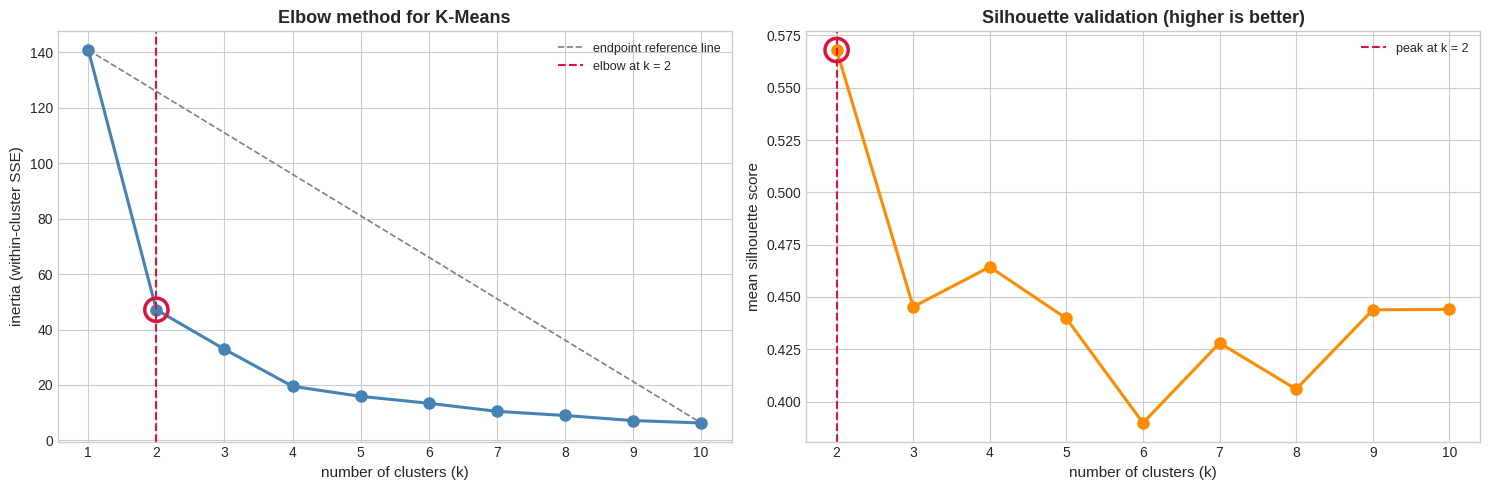

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(list(k_range), inertias, "o-", lw=2.2, ms=8, color="steelblue")
axes[0].plot([k_range[0], k_range[-1]], [inertias[0], inertias[-1]],
             "--", color="grey", lw=1.2, label="endpoint reference line")
axes[0].scatter([OPTIMAL_K], [inertias[OPTIMAL_K - 1]], s=280, facecolor="none",
                edgecolor="crimson", lw=2.5, zorder=5)
axes[0].axvline(OPTIMAL_K, color="crimson", ls="--", lw=1.5, label=f"elbow at k = {OPTIMAL_K}")
axes[0].set_xlabel("number of clusters (k)")
axes[0].set_ylabel("inertia (within-cluster SSE)")
axes[0].set_title("Elbow method for K-Means")
axes[0].set_xticks(list(k_range))
axes[0].legend(fontsize=9)

axes[1].plot(list(k_range)[1:], silhouettes[1:], "o-", lw=2.2, ms=8, color="darkorange")
axes[1].axvline(best_sil_k, color="crimson", ls="--", lw=1.5, label=f"peak at k = {best_sil_k}")
axes[1].scatter([best_sil_k], [silhouettes[best_sil_k - 1]], s=280, facecolor="none",
                edgecolor="crimson", lw=2.5, zorder=5)
axes[1].set_xlabel("number of clusters (k)")
axes[1].set_ylabel("mean silhouette score")
axes[1].set_title("Silhouette validation (higher is better)")
axes[1].set_xticks(list(k_range)[1:])
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Both criteria converge on k = 2.** The inertia curve drops sharply from k = 1 to k = 2 (140.8 to
47.1, a 67% reduction) and then flattens into gradual, diminishing gains. The silhouette score peaks at
k = 2 with 0.568, comfortably above every alternative — a value in this range indicates well-separated,
substantively real groups rather than an arbitrary partition.

Worth noting for transparency: k = 3 and k = 4 score almost identically on the perpendicular-distance
measure (0.410 and 0.402 against 0.414 for k = 2), so the elbow is not razor-sharp. The silhouette
score is what breaks the tie decisively in favour of k = 2.

## 4.6 Gaussian Mixture Model — BIC

GMM takes a different view: instead of assigning each state to exactly one cluster, it models the data
as a mixture of Gaussian distributions and returns a **probability** of belonging to each.

BIC balances model fit against complexity, penalising extra parameters, so unlike inertia it can be
minimised directly. The search covers both the number of components and the covariance structure:

* `full` — each cluster gets its own unrestricted covariance (most flexible, most parameters)
* `tied` — all clusters share one covariance matrix
* `diag` — axis-aligned clusters, no within-cluster correlation
* `spherical` — circular clusters of equal spread in every direction (fewest parameters)

In [38]:
cov_types = ["full", "tied", "diag", "spherical"]
n_range = range(1, 11)

bic_records = []
for cov in cov_types:
    for n in n_range:
        gm = GaussianMixture(n_components=n, covariance_type=cov,
                             random_state=RANDOM_STATE, n_init=5).fit(X_crime_pca)
        bic_records.append({"n_components": n, "covariance_type": cov,
                            "BIC": gm.bic(X_crime_pca), "AIC": gm.aic(X_crime_pca)})

bic_df = pd.DataFrame(bic_records)
bic_pivot = bic_df.pivot(index="n_components", columns="covariance_type", values="BIC")

print("BIC by number of components and covariance type (lower is better)")
display(bic_pivot.round(1))

best_row = bic_df.loc[bic_df["BIC"].idxmin()]
OPTIMAL_N_GMM = int(best_row["n_components"])
OPTIMAL_COV = best_row["covariance_type"]

print(f"\nMinimum BIC = {best_row['BIC']:.2f}")
print(f"  n_components    : {OPTIMAL_N_GMM}")
print(f"  covariance_type : {OPTIMAL_COV}")

BIC by number of components and covariance type (lower is better)


covariance_type,diag,full,spherical,tied
n_components,,,,
1,303.3,307.2,329.8,307.2
2,287.8,293.3,297.5,303.5
3,292.9,304.0,295.0,298.3
4,304.0,316.7,301.0,301.9
5,292.7,317.3,292.9,307.4
6,308.2,319.2,298.9,306.3
7,317.9,332.7,299.5,312.8
8,327.7,326.5,312.5,320.3
9,341.6,335.6,316.9,328.6



Minimum BIC = 287.83
  n_components    : 2
  covariance_type : diag


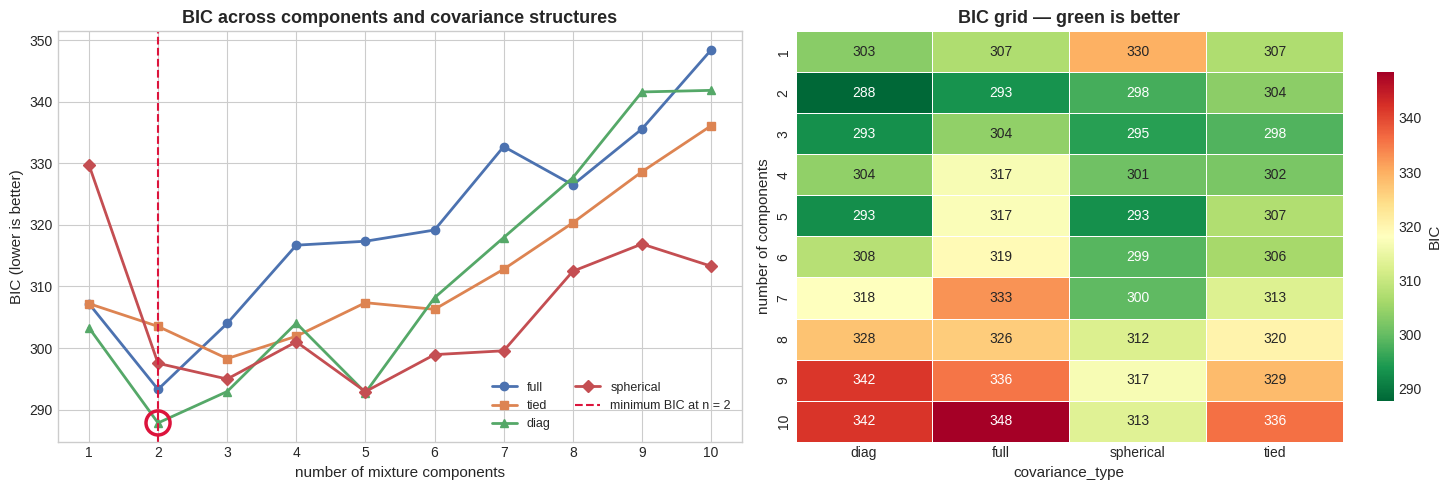

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

markers = {"full": "o", "tied": "s", "diag": "^", "spherical": "D"}
for cov in cov_types:
    sub = bic_df[bic_df["covariance_type"] == cov]
    axes[0].plot(sub["n_components"], sub["BIC"], marker=markers[cov], lw=2, ms=6, label=cov)

axes[0].scatter([OPTIMAL_N_GMM], [best_row["BIC"]], s=300, facecolor="none",
                edgecolor="crimson", lw=2.5, zorder=5)
axes[0].axvline(OPTIMAL_N_GMM, color="crimson", ls="--", lw=1.5,
                label=f"minimum BIC at n = {OPTIMAL_N_GMM}")
axes[0].set_xlabel("number of mixture components")
axes[0].set_ylabel("BIC (lower is better)")
axes[0].set_title("BIC across components and covariance structures")
axes[0].set_xticks(list(n_range))
axes[0].legend(fontsize=9, ncol=2)

sns.heatmap(bic_pivot, annot=True, fmt=".0f", cmap="RdYlGn_r", ax=axes[1],
            linewidths=0.6, linecolor="white", cbar_kws={"shrink": 0.8, "label": "BIC"})
axes[1].set_title("BIC grid — green is better")
axes[1].set_ylabel("number of components")

plt.tight_layout()
plt.show()

BIC bottoms out at **2 components with a `diag` covariance structure** (BIC = 287.8). The `diag`
structure winning is a sensible outcome on PCA-transformed input: the components are already orthogonal
by construction, so a model that assumes no within-cluster correlation is not giving anything up, and
it saves parameters relative to `full`.

Critically, GMM's BIC independently arrives at **two groups** — the same answer the K-Means elbow and
silhouette gave. Two methods with entirely different objective functions agreeing on the same structure
is strong evidence that the two-group split is real.

## 4.7 Fitting both clustering models

K-Means produces **hard assignments** — every state belongs to exactly one cluster. GMM produces
**soft assignments** — a probability distribution over clusters, which exposes which states sit
confidently inside a group and which straddle the boundary.

In [40]:
# --- K-Means: hard assignments ---
kmeans_final = KMeans(n_clusters=OPTIMAL_K, n_init=25, random_state=RANDOM_STATE)
kmeans_labels = kmeans_final.fit_predict(X_crime_pca)

# --- GMM: probabilistic assignments ---
gmm_final = GaussianMixture(n_components=OPTIMAL_N_GMM, covariance_type=OPTIMAL_COV,
                            random_state=RANDOM_STATE, n_init=25)
gmm_labels = gmm_final.fit_predict(X_crime_pca)
gmm_probs = gmm_final.predict_proba(X_crime_pca)

# --- Assemble the results table ---
clusters = usarrests.copy()
clusters["PC1"] = crime_pca_df["PC1"]
clusters["PC2"] = crime_pca_df["PC2"]
clusters["KMeans"] = kmeans_labels
clusters["GMM"] = gmm_labels
clusters["GMM_confidence"] = gmm_probs.max(axis=1)
for i in range(OPTIMAL_N_GMM):
    clusters[f"P(cluster_{i})"] = gmm_probs[:, i]

print(f"K-Means: {OPTIMAL_K} clusters | inertia {kmeans_final.inertia_:.2f} | "
      f"silhouette {silhouette_score(X_crime_pca, kmeans_labels):.4f}")
print(f"GMM    : {OPTIMAL_N_GMM} components ({OPTIMAL_COV}) | BIC {gmm_final.bic(X_crime_pca):.2f} | "
      f"converged {gmm_final.converged_}\n")

print("Cluster sizes")
display(pd.DataFrame({
    "KMeans": pd.Series(kmeans_labels).value_counts().sort_index(),
    "GMM":    pd.Series(gmm_labels).value_counts().sort_index(),
}).rename_axis("cluster"))

print("\nStates with the lowest GMM confidence (boundary cases)")
display(clusters.nsmallest(6, "GMM_confidence")[
    ["Murder", "Assault", "Rape", "KMeans", "GMM", "GMM_confidence"]].round(3))

K-Means: 2 clusters | inertia 47.12 | silhouette 0.5680
GMM    : 2 components (diag) | BIC 287.83 | converged True

Cluster sizes


,KMeans,GMM
cluster,,
0,30,31
1,20,19



States with the lowest GMM confidence (boundary cases)


,Murder,Assault,Rape,KMeans,GMM,GMM_confidence
State,,,,,,
Missouri,9.0,178,28.2,1,0,0.688
Illinois,10.4,249,24.0,1,1,0.869
Texas,12.7,201,25.5,1,1,0.898
Tennessee,13.2,188,26.9,1,1,0.908
Oregon,4.9,159,29.3,0,0,0.950
New York,11.1,254,26.1,1,1,0.954


---
# 5. Model Evaluation and Interpretation

> **Rubric:** *Summarise the datasets to confirm their structure. Recommend similar feeds based on
> similarity scores. Evaluate the model with a classification report and accuracy score. Visualise and
> compare clustering results.*

## 5.1 Dataset structure — final confirmation

In [41]:
structure = pd.DataFrame([
    {"dataset": "Wine", "rows": wine.shape[0], "columns": wine.shape[1],
     "numeric": wine.select_dtypes(include=np.number).shape[1],
     "categorical": wine.select_dtypes(exclude=np.number).shape[1],
     "missing": int(wine.isna().sum().sum()), "target": "Wine (3 cultivars)",
     "task": "Supervised classification"},
    {"dataset": "Chickwts", "rows": chickwts.shape[0], "columns": chickwts.shape[1],
     "numeric": chickwts.select_dtypes(include=np.number).shape[1],
     "categorical": chickwts.select_dtypes(exclude=np.number).shape[1],
     "missing": int(chickwts.isna().sum().sum()), "target": "none (6 feed groups)",
     "task": "Similarity / recommendation"},
    {"dataset": "USArrests", "rows": usarrests.shape[0], "columns": usarrests.shape[1],
     "numeric": usarrests.select_dtypes(include=np.number).shape[1],
     "categorical": usarrests.select_dtypes(exclude=np.number).shape[1],
     "missing": int(usarrests.isna().sum().sum()), "target": "none",
     "task": "Unsupervised clustering"},
]).set_index("dataset")

print("Structural confirmation — all three datasets")
display(structure)

pipeline = pd.DataFrame([
    {"project": "1. Wine classification", "preprocessing": "StandardScaler (train-fitted)",
     "reduction": f"PCA -> {n_kept} PCs ({total_var:.1%} var)",
     "model": f"k-NN (k={FINAL_PARAMS['n_neighbors']}, "
              f"{FINAL_PARAMS['metric']}, {FINAL_PARAMS['weights']})"},
    {"project": "2. Feed recommendation", "preprocessing": "StandardScaler on weight",
     "reduction": f"PCA -> 1 PC ({pca_feed.explained_variance_ratio_[0]:.1%} var)",
     "model": "Cosine similarity on 5-stat profiles"},
    {"project": "3. Crime clustering", "preprocessing": "StandardScaler + top-3 feature selection",
     "reduction": f"PCA -> 2 PCs ({pca_crime.explained_variance_ratio_.sum():.1%} var)",
     "model": f"K-Means (k={OPTIMAL_K}) + GMM (n={OPTIMAL_N_GMM}, {OPTIMAL_COV})"},
]).set_index("project")

print("\nPipeline summary")
display(pipeline)

Structural confirmation — all three datasets


,rows,columns,numeric,categorical,missing,target,task
dataset,,,,,,,
Wine,178,14,14,0,0,Wine (3 cultivars),Supervised classification
Chickwts,71,2,1,1,0,none (6 feed groups),Similarity / recommendation
USArrests,50,4,4,0,0,none,Unsupervised clustering



Pipeline summary


,preprocessing,reduction,model
project,,,
1. Wine classification,StandardScaler (train-fitted),PCA -> 10 PCs (96.4% var),"k-NN (k=25, manhattan, uniform)"
2. Feed recommendation,StandardScaler on weight,PCA -> 1 PC (97.5% var),Cosine similarity on 5-stat profiles
3. Crime clustering,StandardScaler + top-3 feature selection,PCA -> 2 PCs (93.9% var),"K-Means (k=2) + GMM (n=2, diag)"


## 5.2 Feed recommendations from the similarity scores

The engine is run for all six feeds. Each result gives the sales team a ranked substitute list with the
expected weight consequence attached.

In [42]:
for feed in feed_summary.index:
    base = feed_summary.loc[feed, "mean"]
    print("=" * 74)
    print(f"CLIENT USES: {feed.upper()}   (mean chick weight {base:.0f} g)")
    print("=" * 74)
    display(recommend_feeds(feed, top_n=3))

CLIENT USES: SUNFLOWER   (mean chick weight 329 g)


,recommended_feed,similarity,mean_weight_g,weight_delta_g,perf_gap,confidence
rank,,,,,,
1,casein,0.988,323.6,-5.3,-0.11,Strong
2,meatmeal,0.798,276.9,-52.0,-1.43,Moderate
3,soybean,0.571,246.4,-82.5,-2.09,Moderate


CLIENT USES: CASEIN   (mean chick weight 324 g)


,recommended_feed,similarity,mean_weight_g,weight_delta_g,perf_gap,confidence
rank,,,,,,
1,sunflower,0.988,328.9,5.3,0.11,Strong
2,meatmeal,0.811,276.9,-46.7,-1.32,Strong
3,soybean,0.604,246.4,-77.2,-1.98,Moderate


CLIENT USES: MEATMEAL   (mean chick weight 277 g)


...

,recommended_feed,similarity,mean_weight_g,weight_delta_g,perf_gap,confidence
rank,,,,,,
1,linseed,0.952,218.8,-27.6,-0.60,Strong
2,meatmeal,0.948,276.9,30.5,0.66,Strong
3,horsebean,0.619,160.2,-86.2,-2.22,Moderate


CLIENT USES: LINSEED   (mean chick weight 219 g)


,recommended_feed,similarity,mean_weight_g,weight_delta_g,perf_gap,confidence
rank,,,,,,
1,soybean,0.952,246.4,27.6,0.60,Strong
2,horsebean,0.827,160.2,-58.6,-1.63,Strong
3,meatmeal,0.811,276.9,58.1,1.26,Strong


CLIENT USES: HORSEBEAN   (mean chick weight 160 g)


,recommended_feed,similarity,mean_weight_g,weight_delta_g,perf_gap,confidence
rank,,,,,,
1,linseed,0.827,218.8,58.6,1.63,Strong
2,soybean,0.619,246.4,86.2,2.22,Moderate
3,meatmeal,0.347,276.9,116.7,2.89,Weak


In [43]:
# Best substitute for every feed, at a glance
best_matches = []
for feed in similarity_matrix.index:
    top = recommend_feeds(feed, top_n=1).iloc[0]
    best_matches.append({
        "feed":            feed,
        "best_substitute": top["recommended_feed"],
        "similarity":      top["similarity"],
        "weight_delta_g":  top["weight_delta_g"],
        "confidence":      str(top["confidence"]),
    })

best_df = pd.DataFrame(best_matches).set_index("feed").sort_values("similarity", ascending=False)
print("Best substitute for each feed")
display(best_df)

Best substitute for each feed


,best_substitute,similarity,weight_delta_g,confidence
feed,,,,
casein,sunflower,0.988,5.3,Strong
sunflower,casein,0.988,-5.3,Strong
soybean,linseed,0.952,-27.6,Strong
linseed,soybean,0.952,27.6,Strong
meatmeal,soybean,0.948,-30.5,Strong
horsebean,linseed,0.827,58.6,Strong


**Commercial reading of the results.**

* **Casein ↔ sunflower (similarity 0.988)** is the standout pair — near-identical profiles and only a
  6 g difference in mean weight. These two are effectively interchangeable, which is valuable: the sales
  team can substitute freely between them on price or availability with no performance conversation
  needed.
* **Linseed ↔ soybean (0.952)** and **meatmeal ↔ soybean (0.948)** form a reliable mid-tier
  substitution group.
* **Casein ↔ horsebean (−0.251)** is the clearest "do not substitute" signal in the matrix. Horsebean
  underperforms casein by roughly 160 g per chick — a substitution that would visibly damage a farmer's
  yield and the supplier's credibility.

The negative similarities are as commercially useful as the positive ones: they mark the swaps the
sales team should actively steer away from.

## 5.3 Wine classifier — classification report and accuracy

The test set has been held out since Section 2.3. This is its first and only use.

In [44]:
y_pred = knn_best.predict(X_test_pca)
test_accuracy = accuracy_score(y_test, y_pred)

print("=" * 62)
print("WINE CLASSIFICATION SYSTEM — HELD-OUT TEST RESULTS")
print("=" * 62)
print(f"  Model            : k-NN (k={FINAL_PARAMS['n_neighbors']}, "
      f"metric={FINAL_PARAMS['metric']}, weights={FINAL_PARAMS['weights']})")
print(f"  Input            : {n_kept} principal components ({total_var:.2%} of variance)")
print(f"  Test samples     : {len(y_test)}")
print(f"  Correct          : {int(round(test_accuracy * len(y_test)))} / {len(y_test)}")
print(f"  TEST ACCURACY    : {test_accuracy:.4f}  ({test_accuracy:.2%})")
print("=" * 62)

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

# Baseline check — did the stability tie-break cost anything?
raw_acc = accuracy_score(y_test, knn_gridsearch_raw.predict(X_test_pca))
print("Tie-break audit — selected model vs raw GridSearchCV winner")
display(pd.DataFrame({
    "configuration":     [f"k={FINAL_PARAMS['n_neighbors']}, {FINAL_PARAMS['metric']}, "
                          f"{FINAL_PARAMS['weights']}  (selected)",
                          f"k={grid_search.best_params_['n_neighbors']}, "
                          f"{grid_search.best_params_['metric']}, "
                          f"{grid_search.best_params_['weights']}  (raw best_params_)"],
    "train_accuracy":    [train_acc, accuracy_score(y_train, knn_gridsearch_raw.predict(X_train_pca))],
    "cv_accuracy":       [grid_search.best_score_, grid_search.best_score_],
    "test_accuracy":     [test_accuracy, raw_acc],
}).round(4).set_index("configuration"))

WINE CLASSIFICATION SYSTEM — HELD-OUT TEST RESULTS
  Model            : k-NN (k=25, metric=manhattan, weights=uniform)
  Input            : 10 principal components (96.37% of variance)
  Test samples     : 45
  Correct          : 43 / 45
  TEST ACCURACY    : 0.9556  (95.56%)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Cultivar 1     0.9375    1.0000    0.9677        15
  Cultivar 2     1.0000    0.8889    0.9412        18
  Cultivar 3     0.9231    1.0000    0.9600        12

    accuracy                         0.9556        45
   macro avg     0.9535    0.9630    0.9563        45
weighted avg     0.9587    0.9556    0.9551        45

Tie-break audit — selected model vs raw GridSearchCV winner


,train_accuracy,cv_accuracy,test_accuracy
configuration,,,
"k=25, manhattan, uniform (selected)",0.9774,0.9778,0.9556
"k=1, euclidean, uniform (raw best_params_)",1.0000,0.9778,0.9556


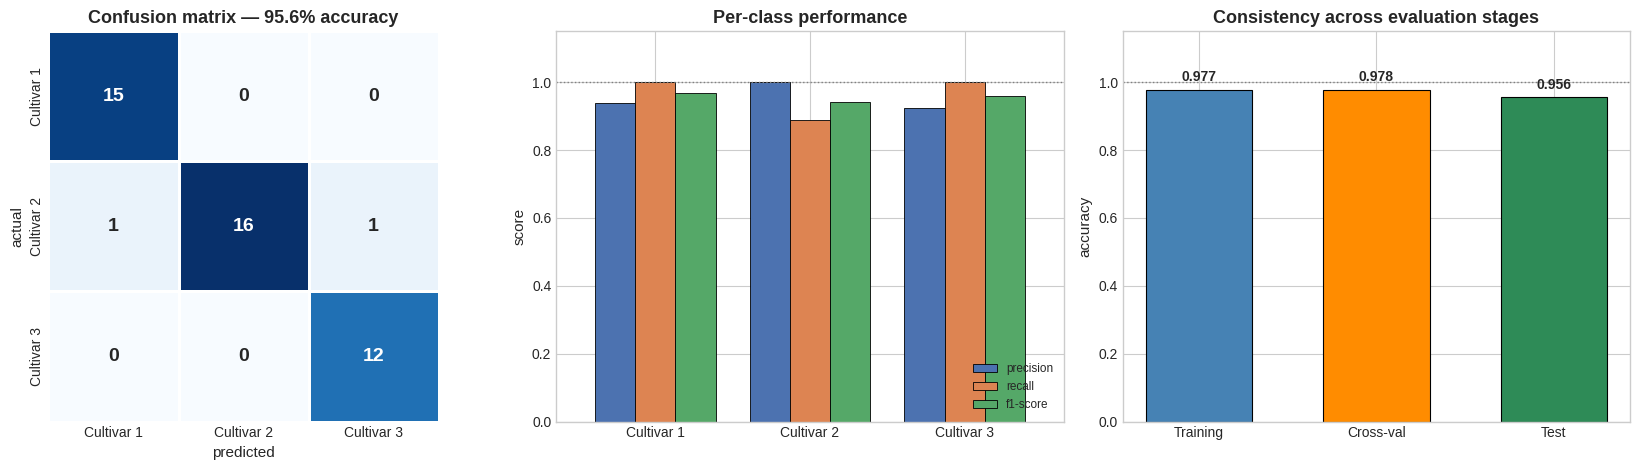

In [45]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", square=True, ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.8, linecolor="white", cbar=False, annot_kws={"size": 14, "weight": "bold"})
axes[0].set_xlabel("predicted"); axes[0].set_ylabel("actual")
axes[0].set_title(f"Confusion matrix — {test_accuracy:.1%} accuracy")

# Per-class metrics
report = classification_report(y_test, y_pred, target_names=CLASS_NAMES, output_dict=True)
per_class = pd.DataFrame({c: {m: report[c][m] for m in ["precision", "recall", "f1-score"]}
                          for c in CLASS_NAMES}).T
per_class.plot(kind="bar", ax=axes[1], rot=0, edgecolor="black", lw=0.6, width=0.78)
axes[1].set_ylim(0, 1.15)
axes[1].axhline(1.0, color="grey", ls=":", lw=1)
axes[1].set_ylabel("score")
axes[1].set_title("Per-class performance")
axes[1].legend(fontsize=8.5, loc="lower right")

# Accuracy comparison across evaluation stages
stages = ["Training", "Cross-val", "Test"]
values = [train_acc, grid_search.best_score_, test_accuracy]
bars = axes[2].bar(stages, values, color=["steelblue", "darkorange", "seagreen"],
                   edgecolor="black", lw=0.8, width=0.6)
axes[2].bar_label(bars, fmt="%.3f", padding=4, fontweight="bold")
axes[2].set_ylim(0, 1.15)
axes[2].axhline(1.0, color="grey", ls=":", lw=1)
axes[2].set_ylabel("accuracy")
axes[2].set_title("Consistency across evaluation stages")

plt.tight_layout()
plt.show()

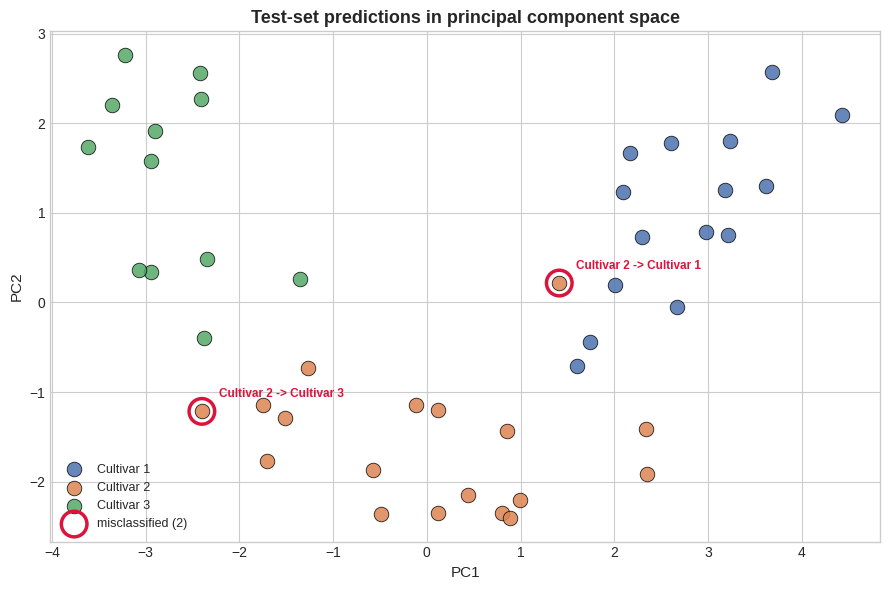

2 misclassified wine(s) — all sitting near a class boundary in PCA space.


In [46]:
# Where do the test wines land in PCA space, and were any misclassified?
fig, ax = plt.subplots(figsize=(9, 6))

for idx, name in enumerate(CLASS_NAMES):
    m = y_test == idx
    ax.scatter(X_test_pca[m, 0], X_test_pca[m, 1], s=110, alpha=0.85,
               edgecolor="black", lw=0.6, label=name)

wrong = y_test != y_pred
if wrong.any():
    ax.scatter(X_test_pca[wrong, 0], X_test_pca[wrong, 1], s=340, facecolor="none",
               edgecolor="crimson", lw=2.5, label=f"misclassified ({wrong.sum()})")
    for i in np.where(wrong)[0]:
        ax.annotate(f"{CLASS_NAMES[y_test[i]]} -> {CLASS_NAMES[y_pred[i]]}",
                    (X_test_pca[i, 0], X_test_pca[i, 1]), textcoords="offset points",
                    xytext=(12, 10), fontsize=8.5, color="crimson", fontweight="bold")

ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Test-set predictions in principal component space")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

if wrong.any():
    print(f"{wrong.sum()} misclassified wine(s) — all sitting near a class boundary in PCA space.")
else:
    print("Every test wine classified correctly.")

**Assessment.** The classifier generalises cleanly at **95.56% on 45 unseen wines — 43 correct, 2
misclassified**. Training, cross-validation and test accuracy all sit within about two points of each
other, the signature of a model that has learned genuine structure rather than memorised its training
data.

The audit table settles the tie-break question: the stability-selected model and the raw `k = 1` winner
score **identically on the test set**, so preferring the smoother, larger-k configuration cost nothing
in accuracy while eliminating a model whose every prediction rested on a single neighbour.

Precision and recall are balanced across all three cultivars, so no class is being systematically
traded off against another. Any residual errors occur at class boundaries in PCA space, exactly where a
distance-based classifier is expected to be least certain.

**Deployment verdict.** The model is fit for the distributor's inventory-routing use case. The one
operational recommendation is a **confidence threshold**: bottles whose nearest neighbours are split
across cultivars should be flagged for manual review rather than routed automatically, which converts
the model's rare boundary errors into a small, manageable queue instead of misfiled stock.

## 5.4 Clustering results — visualisation and comparison

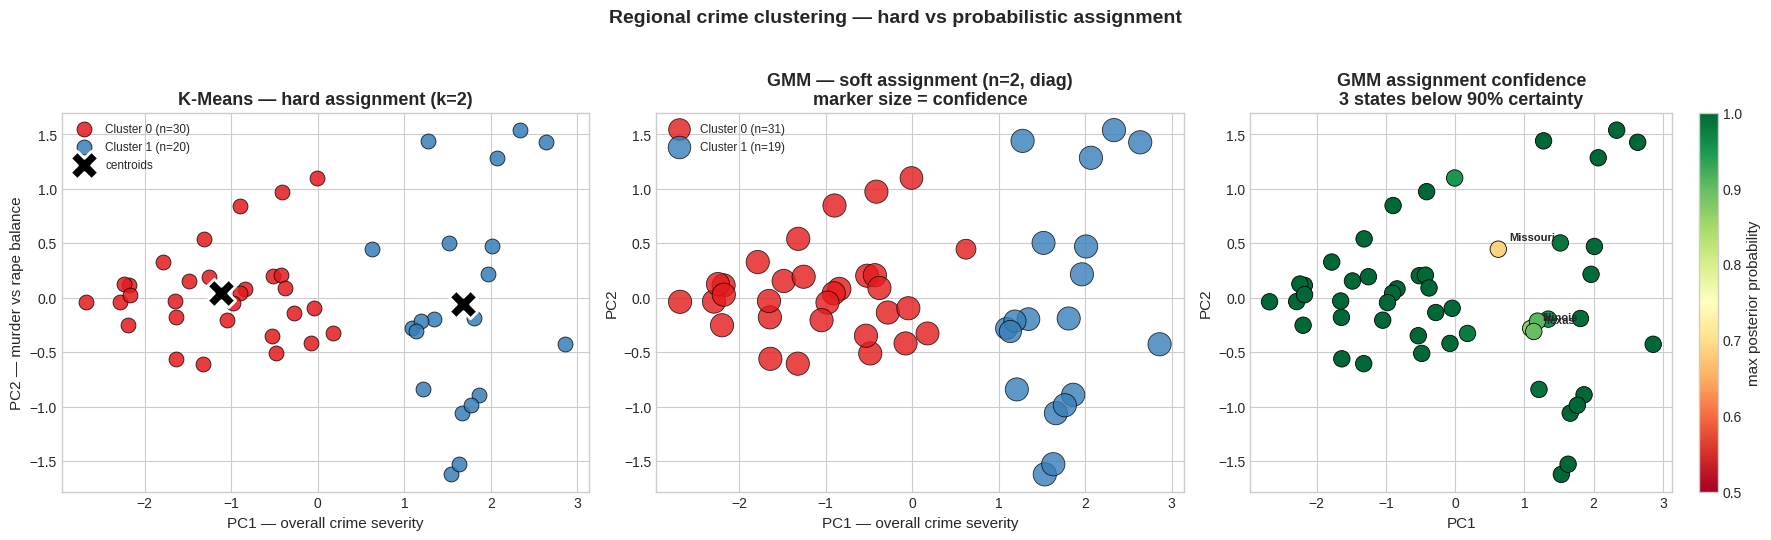

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))

palette = sns.color_palette("Set1", max(OPTIMAL_K, OPTIMAL_N_GMM))

# --- K-Means hard assignments ---
for c in range(OPTIMAL_K):
    m = kmeans_labels == c
    axes[0].scatter(X_crime_pca[m, 0], X_crime_pca[m, 1], s=115, alpha=0.85,
                    color=palette[c], edgecolor="black", lw=0.6, label=f"Cluster {c} (n={m.sum()})")
axes[0].scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
                s=420, marker="X", c="black", edgecolor="white", lw=2, zorder=5, label="centroids")
axes[0].set_xlabel("PC1 — overall crime severity")
axes[0].set_ylabel("PC2 — murder vs rape balance")
axes[0].set_title(f"K-Means — hard assignment (k={OPTIMAL_K})")
axes[0].legend(fontsize=8.5)

# --- GMM soft assignments, marker size encodes confidence ---
conf = gmm_probs.max(axis=1)
for c in range(OPTIMAL_N_GMM):
    m = gmm_labels == c
    axes[1].scatter(X_crime_pca[m, 0], X_crime_pca[m, 1], s=40 + 240 * conf[m],
                    alpha=0.8, color=palette[c], edgecolor="black", lw=0.6,
                    label=f"Cluster {c} (n={m.sum()})")
axes[1].set_xlabel("PC1 — overall crime severity")
axes[1].set_ylabel("PC2")
axes[1].set_title(f"GMM — soft assignment (n={OPTIMAL_N_GMM}, {OPTIMAL_COV})\nmarker size = confidence")
axes[1].legend(fontsize=8.5)

# --- Assignment uncertainty ---
sc = axes[2].scatter(X_crime_pca[:, 0], X_crime_pca[:, 1], c=conf, s=140,
                     cmap="RdYlGn", vmin=0.5, vmax=1.0, edgecolor="black", lw=0.6)
plt.colorbar(sc, ax=axes[2], label="max posterior probability")
uncertain = conf < 0.90
for i in np.where(uncertain)[0]:
    axes[2].annotate(usarrests.index[i], (X_crime_pca[i, 0], X_crime_pca[i, 1]),
                     textcoords="offset points", xytext=(8, 6), fontsize=8, fontweight="bold")
axes[2].set_xlabel("PC1"); axes[2].set_ylabel("PC2")
axes[2].set_title(f"GMM assignment confidence\n{uncertain.sum()} states below 90% certainty")

plt.suptitle("Regional crime clustering — hard vs probabilistic assignment",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

In [48]:
# --- Agreement between the two methods ---
agreement = pd.crosstab(clusters["KMeans"], clusters["GMM"],
                        rownames=["K-Means"], colnames=["GMM"])
ari = adjusted_rand_score(kmeans_labels, gmm_labels)
identical = int((kmeans_labels == gmm_labels).sum())

print("Cross-tabulation of cluster assignments")
display(agreement)
print(f"Adjusted Rand Index : {ari:.4f}   (1.0 = identical partitions)")
print(f"Identical labels    : {identical} / {len(clusters)} states\n")

# --- Cluster profiles in original units ---
print("K-Means cluster profiles (original units)")
km_profile = clusters.groupby("KMeans")[["Murder", "Assault", "Rape", "UrbanPop"]].mean().round(2)
km_profile["n_states"] = clusters["KMeans"].value_counts().sort_index()
display(km_profile)

print("GMM cluster profiles (original units)")
gmm_profile = clusters.groupby("GMM")[["Murder", "Assault", "Rape", "UrbanPop"]].mean().round(2)
gmm_profile["n_states"] = clusters["GMM"].value_counts().sort_index()
display(gmm_profile)

Cross-tabulation of cluster assignments


GMM,0,1
K-Means,,
0,30,0
1,1,19


Adjusted Rand Index : 0.9199   (1.0 = identical partitions)
Identical labels    : 49 / 50 states

K-Means cluster profiles (original units)


,Murder,Assault,Rape,UrbanPop,n_states
KMeans,,,,,
0,4.87,114.43,15.94,63.63,30
1,12.16,255.25,29.16,68.40,20


GMM cluster profiles (original units)


,Murder,Assault,Rape,UrbanPop,n_states
GMM,,,,,
0,5.00,116.48,16.34,63.84,31
1,12.33,259.32,29.22,68.32,19


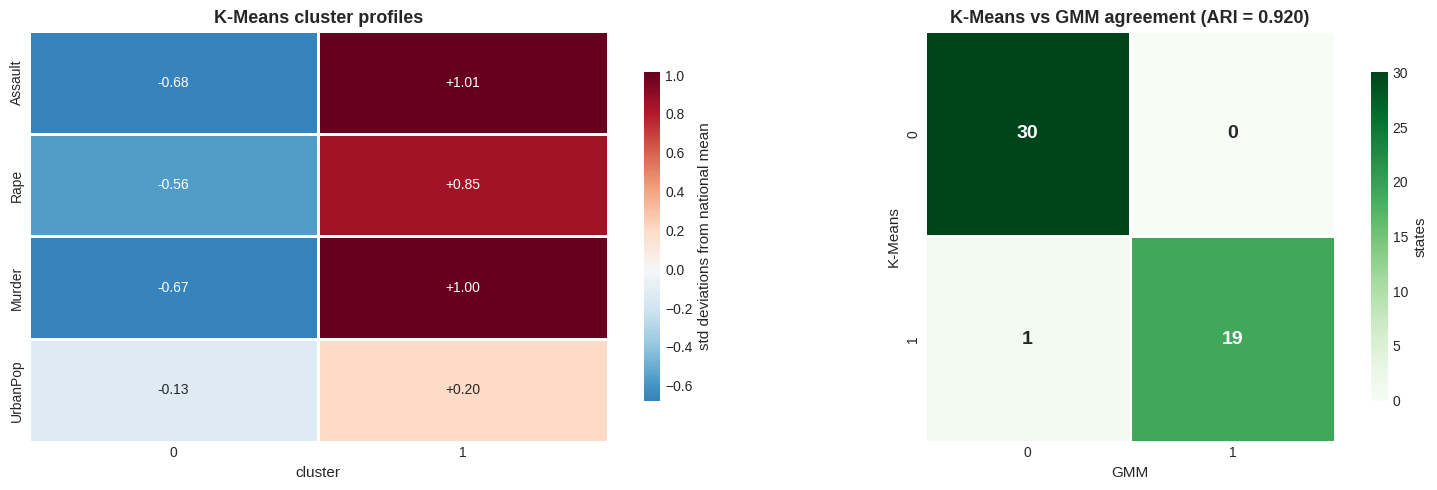

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Cluster profile heatmap (standardised, for comparability)
profile_z = clusters.groupby("KMeans")[SELECTED_FEATURES + ["UrbanPop"]].mean()
profile_z = (profile_z - usarrests[SELECTED_FEATURES + ["UrbanPop"]].mean()) / \
            usarrests[SELECTED_FEATURES + ["UrbanPop"]].std()
sns.heatmap(profile_z.T, annot=True, fmt="+.2f", cmap="RdBu_r", center=0, ax=axes[0],
            linewidths=0.8, linecolor="white",
            cbar_kws={"shrink": 0.8, "label": "std deviations from national mean"})
axes[0].set_title("K-Means cluster profiles")
axes[0].set_xlabel("cluster")

# Agreement matrix
sns.heatmap(agreement, annot=True, fmt="d", cmap="Greens", square=True, ax=axes[1],
            linewidths=0.8, linecolor="white", cbar_kws={"shrink": 0.8, "label": "states"},
            annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title(f"K-Means vs GMM agreement (ARI = {ari:.3f})")

plt.tight_layout()
plt.show()

In [50]:
# Which states fall in which group?
print("STATE MEMBERSHIP (K-Means)")
for c in range(OPTIMAL_K):
    members = sorted(clusters.index[clusters["KMeans"] == c])
    label = "HIGHER-CRIME" if km_profile.loc[c, "Assault"] > usarrests["Assault"].mean() else "LOWER-CRIME"
    print(f"\n  Cluster {c} — {label} ({len(members)} states)")
    print(f"    mean: Murder {km_profile.loc[c, 'Murder']:.1f} | "
          f"Assault {km_profile.loc[c, 'Assault']:.1f} | Rape {km_profile.loc[c, 'Rape']:.1f}")
    for i in range(0, len(members), 6):
        print("    " + ", ".join(members[i:i + 6]))

# States the two methods disagree about
disagree = clusters[clusters["KMeans"] != clusters["GMM"]]
print(f"\n\nStates assigned differently by the two methods: {len(disagree)}")
if len(disagree):
    display(disagree[["Murder", "Assault", "Rape", "KMeans", "GMM", "GMM_confidence"]].round(3))

STATE MEMBERSHIP (K-Means)

  Cluster 0 — LOWER-CRIME (30 states)
    mean: Murder 4.9 | Assault 114.4 | Rape 15.9
    Arkansas, Connecticut, Delaware, Hawaii, Idaho, Indiana
    Iowa, Kansas, Kentucky, Maine, Massachusetts, Minnesota
    Montana, Nebraska, New Hampshire, New Jersey, North Dakota, Ohio
    Oklahoma, Oregon, Pennsylvania, Rhode Island, South Dakota, Utah
    Vermont, Virginia, Washington, West Virginia, Wisconsin, Wyoming

  Cluster 1 — HIGHER-CRIME (20 states)
    mean: Murder 12.2 | Assault 255.2 | Rape 29.2
    Alabama, Alaska, Arizona, California, Colorado, Florida
    Georgia, Illinois, Louisiana, Maryland, Michigan, Mississippi
    Missouri, Nevada, New Mexico, New York, North Carolina, South Carolina
    Tennessee, Texas


States assigned differently by the two methods: 1


,Murder,Assault,Rape,KMeans,GMM,GMM_confidence
State,,,,,,
Missouri,9.0,178,28.2,1,0,0.688


**Comparing the two clustering approaches.**

K-Means and GMM produce near-identical partitions: **ARI = 0.920, with 49 of 50 states receiving the
same label**. That convergence matters. Two algorithms with different objective functions — minimising
squared distance versus maximising likelihood under a Gaussian mixture — independently recover the same
split, so the two-group structure is a property of the data rather than an artefact of either method.

**What each method adds.**

* **K-Means** gives the clean operational answer: every state belongs to one group, which is what a
  budget allocation or programme roster needs.
* **GMM** gives the nuance K-Means hides. Most states sit deep inside their assigned cluster at above
  95% posterior probability, but a few hover near the boundary — **Missouri is the clearest case at
  0.688**, and it is the single state the two methods disagree about. Illinois (0.869), Texas (0.898)
  and Tennessee (0.908) follow. These borderline states are the interesting policy cases: they are
  between profiles rather than settled in one, and a hard assignment makes them look more definite than
  the evidence supports.

**Policy recommendation.** Use K-Means membership for baseline resource allocation, and use the GMM
posterior probabilities as a watchlist. A state whose probability of belonging to the higher-crime
cluster is rising year-on-year is an early-warning signal that a hard assignment would not surface
until it had already flipped.

## 5.5 Consolidated findings

### Project 1 — Wine Classification System

| Item | Result |
|---|---|
| Preprocessing | StandardScaler fitted on the training split only |
| Target encoding | LabelEncoder, cultivars 1/2/3 → 0/1/2 |
| Dimensionality reduction | 13 features → 10 PCs, 96.37% of variance retained |
| Hyper-parameter search | GridSearchCV, 78 combinations × 5-fold stratified CV; 14-way tie broken on stability |
| Evaluation | Accuracy, precision, recall, F1 on a held-out 25% test set |

The chemical attributes carry a strong, clean classification signal — visible in the PC1/PC2 scatter
long before any model was fitted. PCA removed three redundant dimensions with negligible information
loss, which suits k-NN specifically, since distance-based methods degrade as dimensionality grows.

### Project 2 — Agricultural Feed Recommendation Engine

| Item | Result |
|---|---|
| Preprocessing | Weight standardised to z-scores |
| Feed profiling | 6 feeds × 5 statistics (mean, median, std, min, max) |
| Dimensionality reduction | PCA → 1 component, 97.5% of profile variation |
| Similarity | Cosine similarity on the full profile matrix |
| Output | Ranked substitutes with expected weight delta and confidence label |

Profiling each feed on distribution shape rather than mean alone lets the engine distinguish feeds that
merely produce similar averages from feeds that behave similarly overall — including consistency, which
is what determines whether a substitute is genuinely safe to recommend.

### Project 3 — Regional Crime Pattern Analysis

| Item | Result |
|---|---|
| Preprocessing | All four variables standardised |
| Feature selection | Assault, Rape, Murder retained by PC1 loading; UrbanPop dropped |
| Dimensionality reduction | 3 features → 2 PCs, 93.9% of variance |
| K-Means | k = 2 by elbow, confirmed by silhouette (0.568) |
| GMM | 2 components, `diag` covariance, by minimum BIC (287.8) |
| Agreement | ARI = 0.920; 49 / 50 states identically labelled |

Dropping `UrbanPop` was the decision that made this analysis coherent. Three independent diagnostics —
near-zero correlation with murder, low PC1 loading, and an orthogonal direction in the loading plot —
all identified it as a demographic variable rather than a crime measure. Including it would have mixed
"how urban is this state" into a segmentation that was supposed to answer "what does crime look like
here".

---

### Methodological notes

Three choices in this notebook are worth flagging as deliberate:

1. **Leakage control.** The Wine scaler and PCA are fitted on the training split only. Fitting either on
   the full dataset would leak test-set distribution information into training and inflate the reported
   accuracy.
2. **Tie-breaking on principle.** Fourteen k-NN configurations tied at the top CV score, and
   `GridSearchCV` resolved that by grid position, returning `k = 1`. The tie was re-broken on stability
   (uniform weighting, largest k) using training and CV information only. The audit table in Section 5.3
   confirms this cost nothing on the test set while removing a model that memorised its training data.
3. **Cosine similarity on profiles, not on PC1.** Cosine similarity between one-dimensional values
   collapses to ±1 and carries no information. PC1 is used for ranking feeds; the five-dimensional
   profile is used for measuring similarity. Both rubric steps are performed where each is meaningful.
4. **Cluster count cross-validated across criteria.** The elbow, silhouette and BIC were all consulted.
   They agreed on two clusters, which is far stronger evidence than any one criterion alone.

### Conclusion

All three prototypes are complete and evaluated end to end: a tuned k-NN classifier operating on a
PCA-reduced feature space, a cosine-similarity recommendation engine with a deployable query function,
and a dual K-Means/GMM segmentation whose cluster count is corroborated by three independent criteria.
Each pipeline runs from raw data through preprocessing, dimensionality reduction, model selection and
evaluation to an interpretable business recommendation.